# CAM Rows from Llama-8B Truthfulness Probe Directions + LSQ-QAT Euclidean WTA Classifier

This notebook builds a CAM-ready vector bank **without SAE features**. Instead, it uses dense residual-stream directions learned by linear probes, following the setup from *The Truthfulness Spectrum Hypothesis*.

Main configuration used here:

- **Model:** `meta-llama/Llama-3.1-8B-Instruct`
- **Layer:** `15`, the layer identified in the paper for Llama-8B probe generalization
- **Activation source:** residual stream / hidden state from the selected transformer layer
- **Probe architecture:** logistic regression on averaged assistant-output-token activations
- **CAM rows:** linear probe directions, optionally extracted iteratively using INLP
- **Classifier:** WTA classifier over fixed CAM rows with:
  - a configurable learned down-projection from the residual dimension to `PROJECTION_DIM` (default `128`)
  - LSQ-style quantization-aware training at configurable `LSQ_BIT_PRECISION` (default `3`)
  - Euclidean-distance evaluation using baked weighted rows and an extra norm dimension

The notebook trains:

1. One CAM vector bank and WTA classifier per single domain.
2. One combined-domain CAM vector bank and WTA classifier.
3. Optionally, one deployment bank over all rows.
4. Euclidean baked artifacts for CAM-style inference.


In [ ]:
# Optional installs. Run this cell in a fresh Colab/CRC environment.
# If packages are already installed, you can skip it.

%pip install -q torch transformers accelerate datasets scikit-learn pandas numpy tqdm matplotlib seaborn huggingface_hub safetensors bitsandbytes


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## 1. Clone the official paper repository

The paper repo contains the scripts used to create datasets and run the original probe experiments. This notebook uses the same dataset family, but performs a custom extraction/training pipeline for your CAM/WTA setup.

In [ ]:
from pathlib import Path
import os, subprocess, sys, json, glob, re, math, random, pickle, shutil

PROJECT_ROOT = Path.cwd()
TRUTH_SPEC_DIR = PROJECT_ROOT / "truth_spec"

if not TRUTH_SPEC_DIR.exists():
    print("Cloning zfying/truth_spec ...")
    subprocess.run(["git", "clone", "https://github.com/zfying/truth_spec.git", str(TRUTH_SPEC_DIR)], check=True)
else:
    print("Found existing repo:", TRUTH_SPEC_DIR)

# Optional: install repo requirements if available.
req = TRUTH_SPEC_DIR / "requirements.txt"
if req.exists():
    print("Repo requirements found at", req)
    print("If needed, run: %pip install -r", req)

Found existing repo: /localhome/bhaiding/IRES/truth_spec
Repo requirements found at /localhome/bhaiding/IRES/truth_spec/requirements.txt
If needed, run: %pip install -r /localhome/bhaiding/IRES/truth_spec/requirements.txt


## 2. Configuration

Important choices:

- `LAYER_INDEX = 15` because the paper reports Llama-8B's best cross-domain probe layer as layer 15.
- `HIDDEN_STATE_MODE = "post_layer"` means Hugging Face `outputs.hidden_states[LAYER_INDEX + 1]`, i.e. the residual state after layer 15. If you want the input to layer 15 instead, set this to `"pre_layer"`.
- `LABEL_POSITIVE_CLASS = "deceptive"` orients probe directions so positive dot products point toward the target behavior.

In [ ]:
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ---- Model ----
MODEL_ID = "meta-llama/Llama-3.3-70B-Instruct"
LAYER_INDEX = 33
HIDDEN_STATE_MODE = "post_layer"  # "post_layer" -> hidden_states[LAYER_INDEX+1], "pre_layer" -> hidden_states[LAYER_INDEX]
DTYPE = torch.bfloat16  # compute dtype used for de-quantized matmuls/activations
# bitsandbytes only supports 8-bit or 4-bit single-GPU quantization (there is no real
# "12-bit" mode). 8-bit (~70GB for this 70B model) fits on one 80GB H100 with some
# headroom for activations; use 4-bit if you need more headroom.
QUANTIZATION_BITS = 8  # 8 or 4
DEVICE_MAP = {"": 0}  # force the whole model onto one GPU; raises CUDA OOM instead of silently offloading to CPU

# ---- Data / output ----
OUTPUT_DIR = PROJECT_ROOT / "cam_probe_wta_outputs_llama8b_L15"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUTPUT_DIR / "activation_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR = OUTPUT_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# ---- Domains from the paper ----
DOMAINS = [
    "definitional",
    "empirical",
    "fictional",
    "logical",
    "ethical",
    "sycophancy",
    "exp_inverted",
    "roleplaying",
    "insider_trading",
    "sandbagging",
]

# File-name aliases used during discovery.
DATASET_SPECS = {
    "definitional": ["definitional", "definition"],
    "empirical": ["empirical", "evidential", "facts", "factual"],
    "fictional": ["fictional", "fiction"],
    "logical": ["logical", "logic"],
    "ethical": ["ethical", "ethics"],
    "sycophancy": ["sycophancy", "sycophantic"],
    "exp_inverted": ["exp_inverted", "expectation", "inverted", "expectation_inverted"],
    "roleplaying": ["roleplaying", "roleplay"],
    "insider_trading": ["insider", "trading"],
    "sandbagging": ["sandbagging", "sandbag"],
}

# ---- Experiment size ----
# Set to None for full runs. Keep small while debugging.
MAX_EXAMPLES_PER_DOMAIN = None  # e.g. 200 for a quick test
MAX_TOKENS_PER_EXAMPLE_FOR_WTA = 64
# Pooling used to collapse an example's assistant-token activations into one vector.
# "last" matches live token-by-token streaming use (only the current token's activation is
# available); "mean" matches the paper's example-level probes. Changing this requires
# re-extracting activations (it is baked into the activation cache), not just retraining.
POOLING_MODE = "last"  # "last" or "mean"
TRAIN_WTA_ON = "means"  # "tokens" for online-generation-like training, "means" for paper-style example-level training

# ---- OOM-safe activation extraction/cache ----
# For 70B models, keep extraction batch size at 1 unless you have lots of spare GPU memory.
EXTRACT_BATCH_SIZE = 1
# Stores cached residual vectors in half precision on disk. Downstream training casts batches to fp32 only when needed.
ACTIVATION_CACHE_DTYPE = np.float16
# Token-level activations are enormous: n_examples * MAX_TOKENS_PER_EXAMPLE_FOR_WTA * d_model.
# Leave this False when TRAIN_WTA_ON == "means".
EXTRACT_TOKEN_ACTIVATIONS = (TRAIN_WTA_ON == "tokens")
# Flush activation shards while extracting so RAM does not grow with the dataset.
ACTIVATION_SHARD_SIZE = 256
# Use an mmap-backed cache so activations can be loaded without pulling the whole array into RAM.
USE_MMAP_ACTIVATION_CACHE = True
FORCE_REEXTRACT_ACTIVATIONS = False
CLEAR_CUDA_CACHE_EVERY_N_BATCHES = 1
# Batched validation/test scoring avoids moving the whole validation/test split to GPU at once.
EVAL_BATCH_SIZE = 512

# ---- Shared split ----
# One example-level split is created once and reused for both INLP row extraction and WTA training.
SHARED_TEST_FRACTION = 0.20
SHARED_VAL_FRACTION_OF_TRAIN = 0.20

# ---- Direction extraction ----
# Each logistic probe learns one direction. INLP repeats probe training after projecting out previous directions.
N_DIRECTIONS_PER_SINGLE_DOMAIN = 4
N_DIRECTIONS_COMBINED = 10
LOGREG_ALPHA = 1e-4  # paper's Llama-70B final alpha; C=1/alpha in sklearn
USE_STANDARD_SCALER_FOR_PROBES = False  # if True, directions are converted back to raw activation coordinates
REMOVE_GENERAL_BEFORE_SINGLE_DOMAIN = False  # set True for paper-style domain-specific rows after general rows are removed

# ---- Projected WTA + LSQ QAT ----
# Llama-3.1-8B hidden states are usually 4096-dim. This learns a down-projection before WTA.
USE_LEARNED_PROJECTION = True
PROJECTION_DIM = 128          # configurable down-projection dimension
D_PROJ = PROJECTION_DIM       # backwards-compatible alias used by older cells

# LSQ-style quantization-aware training. Start at 3 bits; change this for sweeps.
USE_LSQ_QAT = True
LSQ_BIT_PRECISION = 3
LSQ_SIGNED = True
LSQ_INITIAL_SCALE = None      # None -> initialized from projected vector coordinate scale
LSQ_EPS = 1e-8

# Evaluation mode. "euclidean" uses baked weighted rows + an extra norm dimension.
# "dot" uses max_j alpha_j * dot(q, row_j). They should match up to quantization/numerics.
EVAL_DISTANCE_MODE = "euclidean"

# ---- WTA classifier optimization ----
WTA_EPOCHS = 300
WTA_LR = 3e-2
WTA_WEIGHT_DECAY = 1e-4
BATCH_SIZE = 512  # OOM-safe WTA train batch size; increase only if GPU memory is stable
RANDOM_SEED = 0

# Label convention: y=1 is the behavior CAM should fire on.
# Normal truth domains: false/deceptive = 1, true/honest = 0.
POSITIVE_LABEL_NAME = "deceptive_or_false"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("Output dir:", OUTPUT_DIR)
print("Projection:", {"enabled": USE_LEARNED_PROJECTION, "dim": PROJECTION_DIM})
print("LSQ QAT:", {"enabled": USE_LSQ_QAT, "bits": LSQ_BIT_PRECISION, "eval_mode": EVAL_DISTANCE_MODE})


Output dir: /localhome/bhaiding/IRES/cam_probe_wta_outputs_llama8b_L15
Projection: {'enabled': True, 'dim': 128}
LSQ QAT: {'enabled': True, 'bits': 3, 'eval_mode': 'euclidean'}


## 3. Data discovery and normalization

This loader tries to find the official paper datasets inside `truth_spec/`. Because research repos often change file layouts, the loader is intentionally flexible.

Every row is normalized into:

- `domain`
- `user_prompt`
- `assistant_text`
- `label` where `1 = deceptive/false/lie/target behavior`, `0 = truthful/honest`

If this cell cannot infer your columns automatically, edit `normalize_raw_frame()` for your local dataset files.

In [ ]:
import ast

if "alpaca" not in DATASET_SPECS:
    DATASET_SPECS["alpaca"] = ["alpaca"]

def find_dataset_files(root: Path, domain: str):
    aliases = DATASET_SPECS[domain]
    exts = {".json", ".jsonl", ".csv", ".parquet", ".pkl", ".pickle"}
    candidates = []
    for p in root.rglob("*"):
        if not p.is_file() or p.suffix.lower() not in exts:
            continue
        name = p.name.lower()
        if all(a in name for a in aliases) or any(a in name for a in aliases):
            # Avoid non-data scripts/logs if possible.
            if any(skip in name for skip in ["result", "metric", "plot", "cache", "activation", "feat"]):
                continue
            candidates.append(p)
    return sorted(set(candidates), key=lambda x: (len(str(x)), str(x)))


def read_any_table(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".jsonl":
        return pd.read_json(path, lines=True)
    if suffix == ".json":
        with open(path, "r") as f:
            obj = json.load(f)
        if isinstance(obj, list):
            return pd.DataFrame(obj)
        if isinstance(obj, dict):
            # Common layouts: {"data": [...]}, {split: [...]}, or dict of columns.
            for key in ["data", "train", "examples", "records", "samples"]:
                if key in obj and isinstance(obj[key], list):
                    return pd.DataFrame(obj[key])
            try:
                return pd.DataFrame(obj)
            except Exception:
                rows = []
                for k, v in obj.items():
                    if isinstance(v, list):
                        for item in v:
                            if isinstance(item, dict):
                                item = dict(item)
                                item["_split_or_key"] = k
                                rows.append(item)
                if rows:
                    return pd.DataFrame(rows)
        raise ValueError(f"Unsupported JSON layout: {path}")
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix == ".parquet":
        return pd.read_parquet(path)
    if suffix in {".pkl", ".pickle"}:
        obj = pd.read_pickle(path)
        if isinstance(obj, pd.DataFrame):
            return obj
        return pd.DataFrame(obj)
    raise ValueError(f"Unsupported file suffix: {path}")


def pick_first_existing(row, candidates):
    for c in candidates:
        if c in row:
            val = row[c]
            if isinstance(val, float) and pd.isna(val):
                continue
            if val is not None:
                if isinstance(val, list):
                    if len(val) > 0:
                        return val[0]
                    else:
                        continue
                return val
    return None


def infer_binary_label(row) -> int:
    label_cols = [
        "label", "labels", "label_name", "class", "target", "truth", "truthful", "is_true", "is_truthful",
        "is_false", "is_deceptive", "is_lie", "lie", "deceptive", "honest", "correct", "answer_label",
        "expected_label", "ground_truth", "expect_deception", "graded_deception", "claim_label", "sycophancy_occurred"
    ]
    val = pick_first_existing(row, label_cols)
    if val is None:
        raise ValueError("Could not infer label from row.")

    if isinstance(val, str):
        val = val.strip().lower()
        if val == 'true': val = True
        elif val == 'false': val = False

    if isinstance(val, (bool, np.bool_)):
        for c in ["truth", "truthful", "is_true", "is_truthful", "honest", "correct"]:
            if c in row and pd.notna(row[c]):
                return 0 if bool(row[c]) else 1
        return int(bool(val))
    if isinstance(val, (int, float, np.integer, np.floating)) and not isinstance(val, bool):
        return int(val)

    s = str(val).strip().lower()
    true_words = {"true", "truth", "truthful", "honest", "supported", "correct", "yes", "nondeceptive", "not deceptive", "not_lie", "not lie", "normal", "0"}
    false_words = {"false", "deceptive", "deception", "lie", "lying", "refuted", "incorrect", "wrong", "sycophantic", "dishonest", "sandbag", "sandbagging", "insider_trading", "1"}
    if s in true_words:
        return 0
    if s in false_words:
        return 1
    raise ValueError(f"Unknown label value: {val!r}")


def default_user_prompt_for_domain(domain: str, row=None):
    if domain == "ethical":
        if row is not None:
            action = pick_first_existing(row, ["action", "scenario", "description", "input", "question", "prompt", "user_prompt"])
            if action is not None:
                return str(action)
        return "Is this wrong?"
    return "Please tell me a fact."


def flatten_dict(d, max_depth=3):
    out = dict(d)
    for _ in range(max_depth):
        for k in list(out.keys()):
            # If it's a string that looks like a dict, try to parse it
            if isinstance(out[k], str) and out[k].strip().startswith("{") and out[k].strip().endswith("}"):
                try:
                    out[k] = ast.literal_eval(out[k])
                except:
                    pass
            if isinstance(out[k], dict):
                for sub_k, sub_v in out[k].items():
                    if sub_k not in out:
                        out[sub_k] = sub_v
    return out


def normalize_raw_frame(df: pd.DataFrame, domain: str, source_path: Path) -> pd.DataFrame:
    rows = []
    for _, row in df.iterrows():
        r = flatten_dict(row.to_dict())

        # Handle paired True/False claims datasets explicitly
        if "Claim" in r and "Negated Claim" in r:
            rows.append({
                "domain": domain,
                "user_prompt": "Is this statement true?",
                "assistant_text": str(r["Claim"]),
                "label": 0,
                "source_path": str(source_path),
            })
            rows.append({
                "domain": domain,
                "user_prompt": "Is this statement true?",
                "assistant_text": str(r["Negated Claim"]),
                "label": 1,
                "source_path": str(source_path),
            })
            continue

        assistant_text = pick_first_existing(r, [
            "assistant_text", "assistant", "response", "completion", "generation", "claim", "statement", "text", "answer", "model_response", "output_str", "output_strs", "biography_answer_text"
        ])
        user_prompt = pick_first_existing(r, ["user_prompt", "prompt", "question", "input", "user", "query", "input_str", "input_strs", "plain_messages"])

        if assistant_text is None and "messages" in r and isinstance(r["messages"], (list, tuple)):
            for m in r["messages"]:
                if isinstance(m, dict) and m.get("role") == "assistant":
                    assistant_text = m.get("content")
                    break
            for m in r["messages"]:
                if isinstance(m, dict) and m.get("role") == "user":
                    user_prompt = m.get("content")
                    break

        if assistant_text is None:
            for k, v in r.items():
                if isinstance(v, str) and k not in ["domain", "label", "expected_label", "dataset_class", "base_name", "variant", "model", "rollouts"]:
                    if len(v) > 20 and assistant_text is None:
                        assistant_text = v

        if assistant_text is None:
            continue

        if user_prompt is None or str(user_prompt).strip() == str(assistant_text).strip():
            user_prompt = default_user_prompt_for_domain(domain, r)

        try:
            y = infer_binary_label(r)
        except Exception as e:
            if "is_true" in r:
                y = 0 if bool(r["is_true"]) else 1
            else:
                continue # skip if we still can't infer

        rows.append({
            "domain": domain,
            "user_prompt": str(user_prompt),
            "assistant_text": str(assistant_text),
            "label": int(y),
            "source_path": str(source_path),
        })
    out = pd.DataFrame(rows)
    if len(out) == 0:
        raise ValueError(f"No usable rows parsed from {source_path}")
    out = out[out["label"].isin([0, 1])].reset_index(drop=True)
    return out


def load_domain_dataset(domain: str, root: Path = TRUTH_SPEC_DIR) -> pd.DataFrame:
    files = find_dataset_files(root, domain)
    if not files:
        raise FileNotFoundError(
            f"Could not find a data file for domain={domain!r} under {root}.\n"
            f"Run the official repo data scripts or set DATASET_SPECS / load_domain_dataset manually."
        )
    print(f"\n[{domain}] candidate files:")
    for i, p in enumerate(files[:10]):
        print(f"  {i}: {p}")
    last_error = None
    for p in files:
        try:
            raw = read_any_table(p)
            norm = normalize_raw_frame(raw, domain, p)

            # --- Fix for one-class rollouts like roleplaying ---
            if norm["label"].nunique() < 2 and domain in ["roleplaying", "insider_trading", "sandbagging"]:
                alpaca_files = find_dataset_files(root, "alpaca")
                if alpaca_files:
                    print(f"File {p.name} has only 1 class. Merging with Alpaca to provide honest (label=0) examples...")
                    alpaca_raw = read_any_table(alpaca_files[0])
                    alpaca_norm = normalize_raw_frame(alpaca_raw, domain, alpaca_files[0])
                    # Ensure Alpaca is considered class 0 (honest)
                    alpaca_norm["label"] = 0
                    norm = pd.concat([norm, alpaca_norm]).reset_index(drop=True)
            # ---------------------------------------------------

            if norm["label"].nunique() < 2:
                print("Skipping one-class file", p)
                continue
            if MAX_EXAMPLES_PER_DOMAIN is not None and len(norm) > MAX_EXAMPLES_PER_DOMAIN:
                norm = norm.groupby("label", group_keys=False).apply(
                    lambda g: g.sample(min(len(g), MAX_EXAMPLES_PER_DOMAIN // 2), random_state=RANDOM_SEED)
                ).reset_index(drop=True)
            print(f"Loaded {len(norm)} rows from {p}; label counts: {norm['label'].value_counts().to_dict()}")
            return norm
        except Exception as e:
            last_error = e
            continue
    raise RuntimeError(f"Found candidate files for {domain}, but none parsed successfully. Last error: {last_error}")


def load_all_datasets(domains=DOMAINS):
    frames = []
    missing = []
    for domain in domains:
        try:
            frames.append(load_domain_dataset(domain))
        except Exception as e:
            print(f"WARNING: failed to load {domain}: {e}")
            missing.append(domain)
    if not frames:
        print("No repo domains loaded. Continuing with an empty DataFrame so later HF/custom dataset cells can append rows.")
        return pd.DataFrame(columns=["domain", "user_prompt", "assistant_text", "label", "source_path"])
    data = pd.concat(frames, ignore_index=True)
    print("\nLoaded domains:", sorted(data.domain.unique()))
    print(data.groupby(["domain", "label"]).size())
    if missing:
        print("\nMissing domains:", missing)
    return data

# Load the data.
data = load_all_datasets()
display(data.head())



[definitional] candidate files:
  0: /localhome/bhaiding/IRES/truth_spec/data/claims/claims__definitional_gemini_600_full.csv
Loaded 1186 rows from /localhome/bhaiding/IRES/truth_spec/data/claims/claims__definitional_gemini_600_full.csv; label counts: {0: 593, 1: 593}

[empirical] candidate files:
  0: /localhome/bhaiding/IRES/truth_spec/data/repe/true_false_facts.csv
  1: /localhome/bhaiding/IRES/truth_spec/data/repe/facts_true_false_original.csv
  2: /localhome/bhaiding/IRES/truth_spec/data/internal_state/facts_true_false.csv
  3: /localhome/bhaiding/IRES/truth_spec/data/claims/claims__evidential_gemini_600_full.csv
  4: /localhome/bhaiding/IRES/truth_spec/data/repe/.ipynb_checkpoints/true_false_facts-checkpoint.csv
  5: /localhome/bhaiding/IRES/truth_spec/data/claims/.ipynb_checkpoints/claims__evidential_gemini_600_full-checkpoint.csv
Loaded 612 rows from /localhome/bhaiding/IRES/truth_spec/data/repe/true_false_facts.csv; label counts: {1: 306, 0: 306}

[fictional] candidate files:

Loaded 2160 rows from /localhome/bhaiding/IRES/truth_spec/data/sycophancy/llama-70b-base/mmlu_sycophancy_anatomy.json; label counts: {0: 1556, 1: 604}
Run the official repo data scripts or set DATASET_SPECS / load_domain_dataset manually.

[roleplaying] candidate files:
  0: /localhome/bhaiding/IRES/truth_spec/data/rollouts/roleplaying__plain__llama-8b.json
  1: /localhome/bhaiding/IRES/truth_spec/data/rollouts/roleplaying__plain__llama-70b.json
  2: /localhome/bhaiding/IRES/truth_spec/data/rollouts/roleplaying__plain__llama-70b-3.3.json
File roleplaying__plain__llama-8b.json has only 1 class. Merging with Alpaca to provide honest (label=0) examples...
Loaded 1370 rows from /localhome/bhaiding/IRES/truth_spec/data/rollouts/roleplaying__plain__llama-8b.json; label counts: {0: 999, 1: 371}

[insider_trading] candidate files:
  0: /localhome/bhaiding/IRES/truth_spec/data/rollouts/insider_trading__onpolicy__llama-70b.json
  1: /localhome/bhaiding/IRES/truth_spec/data/rollouts/insider_tradi

,domain,user_prompt,assistant_text,label,source_path
0,definitional,Is this statement true?,A triangle is a polygon with three sides.,0,/localhome/bhaiding/IRES/truth_spec/data/claim...
1,definitional,Is this statement true?,A triangle is a polygon with four sides.,1,/localhome/bhaiding/IRES/truth_spec/data/claim...
2,definitional,Is this statement true?,Water is a molecule consisting of two hydrogen...,0,/localhome/bhaiding/IRES/truth_spec/data/claim...
3,definitional,Is this statement true?,Water is a molecule consisting of three hydrog...,1,/localhome/bhaiding/IRES/truth_spec/data/claim...
4,definitional,Is this statement true?,A bachelor is an unmarried man.,0,/localhome/bhaiding/IRES/truth_spec/data/claim...


In [ ]:
from datasets import load_dataset

new_rows = []

# --- Load TruthfulQA ---
print("Loading TruthfulQA...")
try:
    # We use the 'generation' split which contains a best answer and incorrect answers
    tqa = load_dataset("truthfulqa/truthful_qa", "generation", split="validation")
    for item in tqa:
        question = item['question']
        # label 0: best answer (truthful)
        new_rows.append({
            "domain": "truthfulqa",
            "user_prompt": question,
            "assistant_text": item['best_answer'],
            "label": 0,
            "source_path": "hf://truthful_qa"
        })
        # label 1: sample one incorrect answer (deceptive)
        if len(item['incorrect_answers']) > 0:
            new_rows.append({
                "domain": "truthfulqa",
                "user_prompt": question,
                "assistant_text": item['incorrect_answers'][0],
                "label": 1,
                "source_path": "hf://truthful_qa"
            })
except Exception as e:
    print(f"Failed to load TruthfulQA: {e}")


# --- Load FEVER ---
print("Downloading FEVER dataset directly from Hugging Face Parquet...")
try:
    # Use Hugging Face's auto-converted Parquet file to bypass S3 403 errors and datasets package conflicts
    url = "https://huggingface.co/datasets/fever/fever/resolve/refs%2Fconvert%2Fparquet/v1.0/train/0000.parquet"
    fever_df = pd.read_parquet(url)

    # Filter out 'NOT ENOUGH INFO'
    fever_df = fever_df[fever_df['label'] != 'NOT ENOUGH INFO'].copy()

    # We sample 1000 of each class to keep it manageable and balanced.
    df_truthful = fever_df[fever_df['label'] == 'SUPPORTS'].sample(1000, random_state=RANDOM_SEED)
    df_deceptive = fever_df[fever_df['label'] == 'REFUTES'].sample(1000, random_state=RANDOM_SEED)

    for _, row in df_truthful.iterrows():
        new_rows.append({
            "domain": "fever",
            "user_prompt": "Is this claim true?",
            "assistant_text": row['claim'],
            "label": 0,
            "source_path": "hf://fever_parquet"
        })
    for _, row in df_deceptive.iterrows():
        new_rows.append({
            "domain": "fever",
            "user_prompt": "Is this claim true?",
            "assistant_text": row['claim'],
            "label": 1,
            "source_path": "hf://fever_parquet"
        })
except Exception as e:
    print(f"Failed to load FEVER: {e}")

if new_rows:
    new_data = pd.DataFrame(new_rows)
    # Append to the main dataframe
    data = pd.concat([data, new_data], ignore_index=True)

    # Add to DOMAINS list so the rest of the pipeline picks them up
    for d in ["truthfulqa", "fever"]:
        if d not in DOMAINS and d in new_data["domain"].unique():
            DOMAINS.append(d)

print("\nUpdated data distribution:")
display(data.groupby(["domain", "label"]).size())


Loading TruthfulQA...



Updated data distribution:


domain           label
definitional     0         593
                 1         593
empirical        0         306
                 1         306
fever            0        1000
                 1        1000
fictional        0         600
                 1         600
insider_trading  0          35
                 1          48
logical          0         575
                 1         575
roleplaying      0         999
                 1         371
sandbagging      0         500
                 1         500
sycophancy       0        1556
                 1         604
truthfulqa       0         817
                 1         817
dtype: int64

## 4. Load Llama-8B and extract layer-15 residual stream activations

For each example, the notebook constructs a Llama chat-formatted sequence:

```text
User: <user_prompt>
Assistant: <assistant_text>
```

Then it extracts hidden states only for the assistant-output tokens. It stores:

- `X_mean`: average activation over assistant-output tokens, used for probe-direction extraction like the paper.
- `X_token`: individual assistant-token activations, useful for online CAM-style WTA training.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# If needed, login first in a separate cell:
# from huggingface_hub import login
# login()

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

if QUANTIZATION_BITS == 8:
    bnb_config = BitsAndBytesConfig(load_in_8bit=True)
elif QUANTIZATION_BITS == 4:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=DTYPE,
        bnb_4bit_use_double_quant=True,
    )
else:
    raise ValueError(f"Unsupported QUANTIZATION_BITS={QUANTIZATION_BITS!r}; bitsandbytes supports 8 or 4.")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map=DEVICE_MAP,
    attn_implementation="sdpa",
    low_cpu_mem_usage=True,
)
model.config.output_hidden_states = False
model.config.use_cache = False
model.eval()
print("Loaded", MODEL_ID, f"({QUANTIZATION_BITS}-bit, bitsandbytes)")
print("Layer index:", LAYER_INDEX, "mode:", HIDDEN_STATE_MODE)
print("hf_device_map (should show no 'cpu'/'disk' entries):", getattr(model, "hf_device_map", None))

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


Loaded meta-llama/Llama-3.3-70B-Instruct
Layer index: 33 mode: post_layer


In [ ]:
import gc
import contextlib


def build_chat_ids_and_assistant_span(user_prompt: str, assistant_text: str):
    """Return input_ids and assistant token span [start, end) in the chat-formatted sequence."""
    user_msg = [{"role": "user", "content": user_prompt}]
    full_msg = [
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": assistant_text},
    ]

    prefix_text = tokenizer.apply_chat_template(
        user_msg,
        tokenize=False,
        add_generation_prompt=True,
    )
    full_text = tokenizer.apply_chat_template(
        full_msg,
        tokenize=False,
        add_generation_prompt=False,
    )

    prefix_ids = tokenizer(prefix_text, add_special_tokens=False)["input_ids"]
    full_ids = tokenizer(full_text, add_special_tokens=False)["input_ids"]

    start = len(prefix_ids)
    end = len(full_ids)

    eos_like = {tokenizer.eos_token_id}
    if end > start and full_ids[end - 1] in eos_like:
        end -= 1

    if start >= end:
        assistant_ids = tokenizer(assistant_text, add_special_tokens=False)["input_ids"]
        if len(assistant_ids) == 0:
            raise ValueError("Empty assistant text after tokenization.")
        start = max(0, len(full_ids) - len(assistant_ids))
        end = len(full_ids)
    return torch.tensor(full_ids, dtype=torch.long), start, end


def _get_llama_layer_module(layer_index: int):
    """Works for LlamaForCausalLM-style HF models, including device_map='auto'."""
    base = getattr(model, "model", model)
    if hasattr(base, "layers"):
        return base.layers[layer_index]
    if hasattr(base, "decoder") and hasattr(base.decoder, "layers"):
        return base.decoder.layers[layer_index]
    raise AttributeError("Could not find transformer layers on this model. Edit _get_llama_layer_module().")


def _get_model_input_device():
    """Put input_ids on the embedding device, which matters when device_map='auto'."""
    if hasattr(model, "hf_device_map"):
        for key in ["model.embed_tokens", "model.tok_embeddings", "transformer.wte", "model"]:
            dev = model.hf_device_map.get(key)
            if dev is not None and dev not in {"cpu", "disk"}:
                return torch.device(dev)
    return next(model.parameters()).device


@contextlib.contextmanager
def capture_selected_layer_hidden_state():
    """Capture only one layer's hidden state instead of requesting all hidden_states.

    output_hidden_states=True stores every layer's residual stream. For a 70B model this can
    blow up memory. This hook copies just the selected pre/post layer tensor to CPU.
    """
    layer = _get_llama_layer_module(LAYER_INDEX)
    cache = {}

    def hook(module, inputs, output):
        if HIDDEN_STATE_MODE == "pre_layer":
            hidden = inputs[0]
        elif HIDDEN_STATE_MODE == "post_layer":
            hidden = output[0] if isinstance(output, (tuple, list)) else output
        else:
            raise ValueError(HIDDEN_STATE_MODE)
        cache["hidden"] = hidden.detach().to("cpu", dtype=torch.float32)

    handle = layer.register_forward_hook(hook)
    try:
        yield cache
    finally:
        handle.remove()


@torch.inference_mode()
def extract_one_example(user_prompt: str, assistant_text: str):
    input_ids, start, end = build_chat_ids_and_assistant_span(user_prompt, assistant_text)
    input_ids = input_ids.to(_get_model_input_device()).unsqueeze(0)
    with capture_selected_layer_hidden_state() as layer_cache:
        _ = model(input_ids=input_ids, use_cache=False, output_hidden_states=False, return_dict=True)
    h = layer_cache["hidden"][0, start:end]
    if h.shape[0] == 0:
        raise ValueError("No assistant tokens extracted.")
    del input_ids
    return h


def _activation_cache_dir(cache_path: Path) -> Path:
    return cache_path.with_suffix("").with_name(cache_path.stem + "_mmap")


def _load_mmap_activation_cache(cache_dir: Path):
    manifest_path = cache_dir / "manifest.json"
    if not manifest_path.exists():
        raise FileNotFoundError(manifest_path)
    manifest = json.loads(manifest_path.read_text())
    out = {}
    for name, info in manifest["arrays"].items():
        arr_path = cache_dir / f"{name}.npy"
        mmap = "r" if name.startswith("X_") else None
        out[name] = np.load(arr_path, allow_pickle=False, mmap_mode=mmap)
    print("Loaded mmap activation cache:", cache_dir)
    print({k: v.shape for k, v in out.items() if hasattr(v, "shape")})
    return out


def _write_mmap_activation_cache_from_shards(shard_paths, cache_dir: Path):
    """Create .npy/memmap arrays from shard files without concatenating all shards in RAM."""
    if cache_dir.exists():
        shutil.rmtree(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    if len(shard_paths) == 0:
        raise RuntimeError("No activation shards were written.")

    n_mean = n_tok = 0
    d_model = None
    max_domain_len = 1
    for sp in shard_paths:
        z = np.load(sp, allow_pickle=False)
        n_mean += z["X_mean"].shape[0]
        n_tok += z["X_token"].shape[0]
        if d_model is None and z["X_mean"].ndim == 2 and z["X_mean"].shape[1] > 0:
            d_model = z["X_mean"].shape[1]
        for key in ["domain_mean", "domain_token"]:
            if key in z and len(z[key]):
                max_domain_len = max(max_domain_len, max(len(str(x)) for x in z[key]))
        z.close()

    if d_model is None:
        raise RuntimeError("Could not infer d_model from activation shards.")

    cache_dtype = np.dtype(ACTIVATION_CACHE_DTYPE)
    domain_dtype = f"<U{max_domain_len}"

    arrays = {
        "X_mean": np.lib.format.open_memmap(cache_dir / "X_mean.npy", mode="w+", dtype=cache_dtype, shape=(n_mean, d_model)),
        "y_mean": np.lib.format.open_memmap(cache_dir / "y_mean.npy", mode="w+", dtype=np.int64, shape=(n_mean,)),
        "domain_mean": np.lib.format.open_memmap(cache_dir / "domain_mean.npy", mode="w+", dtype=domain_dtype, shape=(n_mean,)),
        "example_index_mean": np.lib.format.open_memmap(cache_dir / "example_index_mean.npy", mode="w+", dtype=np.int64, shape=(n_mean,)),
        "X_token": np.lib.format.open_memmap(cache_dir / "X_token.npy", mode="w+", dtype=cache_dtype, shape=(n_tok, d_model)),
        "y_token": np.lib.format.open_memmap(cache_dir / "y_token.npy", mode="w+", dtype=np.int64, shape=(n_tok,)),
        "domain_token": np.lib.format.open_memmap(cache_dir / "domain_token.npy", mode="w+", dtype=domain_dtype, shape=(n_tok,)),
        "example_index_token": np.lib.format.open_memmap(cache_dir / "example_index_token.npy", mode="w+", dtype=np.int64, shape=(n_tok,)),
        "token_position": np.lib.format.open_memmap(cache_dir / "token_position.npy", mode="w+", dtype=np.int64, shape=(n_tok,)),
    }

    mean_pos = tok_pos = 0
    for sp in tqdm(shard_paths, desc="Writing mmap activation cache"):
        z = np.load(sp, allow_pickle=False)
        m = z["X_mean"].shape[0]
        t = z["X_token"].shape[0]
        if m:
            arrays["X_mean"][mean_pos:mean_pos + m] = z["X_mean"].astype(cache_dtype, copy=False)
            arrays["y_mean"][mean_pos:mean_pos + m] = z["y_mean"]
            arrays["domain_mean"][mean_pos:mean_pos + m] = z["domain_mean"].astype(domain_dtype, copy=False)
            arrays["example_index_mean"][mean_pos:mean_pos + m] = z["example_index_mean"]
        if t:
            arrays["X_token"][tok_pos:tok_pos + t] = z["X_token"].astype(cache_dtype, copy=False)
            arrays["y_token"][tok_pos:tok_pos + t] = z["y_token"]
            arrays["domain_token"][tok_pos:tok_pos + t] = z["domain_token"].astype(domain_dtype, copy=False)
            arrays["example_index_token"][tok_pos:tok_pos + t] = z["example_index_token"]
            arrays["token_position"][tok_pos:tok_pos + t] = z["token_position"]
        mean_pos += m
        tok_pos += t
        z.close()

    for arr in arrays.values():
        arr.flush()
        del arr

    manifest = {
        "cache_dtype": str(cache_dtype),
        "d_model": int(d_model),
        "extract_token_activations": bool(EXTRACT_TOKEN_ACTIVATIONS),
        "n_mean": int(n_mean),
        "n_token": int(n_tok),
        "arrays": {
            "X_mean": {"dtype": str(cache_dtype), "shape": [int(n_mean), int(d_model)]},
            "y_mean": {"dtype": "int64", "shape": [int(n_mean)]},
            "domain_mean": {"dtype": domain_dtype, "shape": [int(n_mean)]},
            "example_index_mean": {"dtype": "int64", "shape": [int(n_mean)]},
            "X_token": {"dtype": str(cache_dtype), "shape": [int(n_tok), int(d_model)]},
            "y_token": {"dtype": "int64", "shape": [int(n_tok)]},
            "domain_token": {"dtype": domain_dtype, "shape": [int(n_tok)]},
            "example_index_token": {"dtype": "int64", "shape": [int(n_tok)]},
            "token_position": {"dtype": "int64", "shape": [int(n_tok)]},
        },
    }
    (cache_dir / "manifest.json").write_text(json.dumps(manifest, indent=2))
    print("Saved mmap activation cache:", cache_dir)


def extract_or_load_activations(data: pd.DataFrame, cache_path: Path, batch_size: int = EXTRACT_BATCH_SIZE):
    cache_dir = _activation_cache_dir(cache_path)
    if USE_MMAP_ACTIVATION_CACHE and cache_dir.exists() and not FORCE_REEXTRACT_ACTIVATIONS:
        return _load_mmap_activation_cache(cache_dir)
    if cache_path.exists() and not FORCE_REEXTRACT_ACTIVATIONS and not USE_MMAP_ACTIVATION_CACHE:
        print("Loading legacy .npz activation cache:", cache_path)
        obj = np.load(cache_path, allow_pickle=True)
        return {k: obj[k] for k in obj.files}
    if cache_path.exists() and not FORCE_REEXTRACT_ACTIVATIONS and USE_MMAP_ACTIVATION_CACHE:
        print("Ignoring legacy .npz cache because USE_MMAP_ACTIVATION_CACHE=True:", cache_path)
        print("A new mmap-backed cache will be created instead.")

    if FORCE_REEXTRACT_ACTIVATIONS:
        if cache_path.exists():
            print(f"Removing old legacy cache: {cache_path}")
            cache_path.unlink()
        if cache_dir.exists():
            print(f"Removing old mmap cache: {cache_dir}")
            shutil.rmtree(cache_dir)

    shard_dir = cache_path.with_suffix("").with_name(cache_path.stem + "_shards")
    if shard_dir.exists():
        shutil.rmtree(shard_dir)
    shard_dir.mkdir(parents=True, exist_ok=True)
    shard_paths = []

    X_mean, y_mean, domains, ex_indices = [], [], [], []
    X_tok, y_tok, tok_domains, tok_ex_indices, tok_positions = [], [], [], [], []
    n_extracted = 0
    shard_idx = 0
    d_model_seen = None

    def flush_shard(force=False):
        nonlocal shard_idx, X_mean, y_mean, domains, ex_indices, X_tok, y_tok, tok_domains, tok_ex_indices, tok_positions, d_model_seen
        if not X_mean:
            return
        if (not force) and len(X_mean) < ACTIVATION_SHARD_SIZE:
            return

        X_mean_arr = np.stack(X_mean).astype(ACTIVATION_CACHE_DTYPE, copy=False)
        d_model_seen = X_mean_arr.shape[1]
        if X_tok:
            X_tok_arr = np.stack(X_tok).astype(ACTIVATION_CACHE_DTYPE, copy=False)
        else:
            X_tok_arr = np.empty((0, d_model_seen), dtype=ACTIVATION_CACHE_DTYPE)

        shard_path = shard_dir / f"activations_shard_{shard_idx:05d}.npz"
        np.savez(
            shard_path,
            X_mean=X_mean_arr,
            y_mean=np.array(y_mean, dtype=np.int64),
            domain_mean=np.array(domains, dtype=str),
            example_index_mean=np.array(ex_indices, dtype=np.int64),
            X_token=X_tok_arr,
            y_token=np.array(y_tok, dtype=np.int64),
            domain_token=np.array(tok_domains, dtype=str),
            example_index_token=np.array(tok_ex_indices, dtype=np.int64),
            token_position=np.array(tok_positions, dtype=np.int64),
        )
        shard_paths.append(shard_path)
        shard_idx += 1
        X_mean, y_mean, domains, ex_indices = [], [], [], []
        X_tok, y_tok, tok_domains, tok_ex_indices, tok_positions = [], [], [], [], []
        gc.collect()

    tokenizer.padding_side = "right"
    input_device = _get_model_input_device()

    print(
        f"Activation extraction: batch_size={batch_size}, token_activations={EXTRACT_TOKEN_ACTIVATIONS}, "
        f"cache_dtype={np.dtype(ACTIVATION_CACHE_DTYPE)}, mmap_cache={USE_MMAP_ACTIVATION_CACHE}"
    )

    for start_idx in tqdm(range(0, len(data), batch_size), desc="Extracting activations (OOM-safe)"):
        batch_df = data.iloc[start_idx:start_idx + batch_size]
        batch_input_ids, batch_spans, valid_indices = [], [], []

        for i, row in batch_df.iterrows():
            try:
                input_ids, span_start, span_end = build_chat_ids_and_assistant_span(row.user_prompt, row.assistant_text)
                batch_input_ids.append(input_ids)
                batch_spans.append((span_start, span_end))
                valid_indices.append(i)
            except Exception as e:
                print(f"Skipping row {i} due to tokenization/span error: {e}")

        if not batch_input_ids:
            continue

        max_len = max(len(ids) for ids in batch_input_ids)
        padded_ids = torch.full((len(batch_input_ids), max_len), tokenizer.pad_token_id, dtype=torch.long)
        attn_mask = torch.zeros((len(batch_input_ids), max_len), dtype=torch.long)
        for b_idx, ids in enumerate(batch_input_ids):
            padded_ids[b_idx, :len(ids)] = ids
            attn_mask[b_idx, :len(ids)] = 1

        try:
            with torch.inference_mode(), capture_selected_layer_hidden_state() as layer_cache:
                outputs = model(
                    input_ids=padded_ids.to(input_device),
                    attention_mask=attn_mask.to(input_device),
                    use_cache=False,
                    output_hidden_states=False,
                    return_dict=True,
                )

            hidden_states = layer_cache["hidden"]  # CPU float32 [B, T, d]
            del outputs

            for b_idx, (span_start, span_end) in enumerate(batch_spans):
                df_idx = valid_indices[b_idx]
                row = data.loc[df_idx]
                h = hidden_states[b_idx, span_start:span_end]
                if h.shape[0] == 0:
                    print(f"Skipping row {df_idx}: No assistant tokens extracted.")
                    continue

                pooled = h[-1] if POOLING_MODE == "last" else h.mean(dim=0)
                X_mean.append(pooled.numpy())
                y_mean.append(int(row.label))
                domains.append(str(row.domain))
                ex_indices.append(int(df_idx))

                if EXTRACT_TOKEN_ACTIVATIONS:
                    max_t = min(h.shape[0], MAX_TOKENS_PER_EXAMPLE_FOR_WTA)
                    for t in range(max_t):
                        X_tok.append(h[t].numpy())
                        y_tok.append(int(row.label))
                        tok_domains.append(str(row.domain))
                        tok_ex_indices.append(int(df_idx))
                        tok_positions.append(int(t))

                n_extracted += 1

            flush_shard(force=False)

        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"CUDA OOM on batch starting at row {start_idx}. Try lowering EXTRACT_BATCH_SIZE or sequence length. Error: {e}")
                raise
            print(f"Skipping batch starting at {start_idx} due to model error: {e}")
        except Exception as e:
            print(f"Skipping batch starting at {start_idx} due to model error: {e}")
        finally:
            del batch_input_ids, batch_spans, valid_indices, padded_ids, attn_mask
            if "hidden_states" in locals():
                del hidden_states
            gc.collect()
            if torch.cuda.is_available() and (start_idx // max(1, batch_size)) % CLEAR_CUDA_CACHE_EVERY_N_BATCHES == 0:
                torch.cuda.empty_cache()

    flush_shard(force=True)

    if n_extracted == 0:
        raise RuntimeError("All rows failed extraction. Check the tokenizer/model setup.")

    if USE_MMAP_ACTIVATION_CACHE:
        _write_mmap_activation_cache_from_shards(shard_paths, cache_dir)
        # Shards are no longer needed once the mmap cache has been materialized.
        shutil.rmtree(shard_dir, ignore_errors=True)
        return _load_mmap_activation_cache(cache_dir)

    # Fallback legacy path: load all shards into RAM and save a single .npz.
    parts = [np.load(sp, allow_pickle=False) for sp in shard_paths]
    arrays = {k: np.concatenate([p[k] for p in parts], axis=0) for k in parts[0].files}
    for p in parts:
        p.close()
    np.savez(cache_path, **arrays)
    print("Saved activations:", cache_path)
    shutil.rmtree(shard_dir, ignore_errors=True)
    return arrays


cache_path = CACHE_DIR / f"{MODEL_ID.replace('/', '__')}_L{LAYER_INDEX}_{HIDDEN_STATE_MODE}_{POOLING_MODE}pool_{QUANTIZATION_BITS}bit_activations.npz"
acts = extract_or_load_activations(data, cache_path, batch_size=EXTRACT_BATCH_SIZE)
print({k: v.shape for k, v in acts.items() if hasattr(v, "shape")})


Activation extraction: batch_size=1, token_activations=False, cache_dtype=float16, mmap_cache=True


Extracting activations (OOM-safe):   0%|          | 0/12395 [00:00<?, ?it/s]

Writing mmap activation cache:   0%|          | 0/49 [00:00<?, ?it/s]

Saved mmap activation cache: /localhome/bhaiding/IRES/cam_probe_wta_outputs_llama8b_L15/activation_cache/meta-llama__Llama-3.3-70B-Instruct_L33_post_layer_activations_mmap
Loaded mmap activation cache: /localhome/bhaiding/IRES/cam_probe_wta_outputs_llama8b_L15/activation_cache/meta-llama__Llama-3.3-70B-Instruct_L33_post_layer_activations_mmap
{'X_mean': (12395, 8192), 'y_mean': (12395,), 'domain_mean': (12395,), 'example_index_mean': (12395,), 'X_token': (0, 8192), 'y_token': (0,), 'domain_token': (0,), 'example_index_token': (0,), 'token_position': (0,)}
{'X_mean': (12395, 8192), 'y_mean': (12395,), 'domain_mean': (12395,), 'example_index_mean': (12395,), 'X_token': (0, 8192), 'y_token': (0,), 'domain_token': (0,), 'example_index_token': (0,), 'token_position': (0,)}


## 5. Probe directions as CAM rows

A single logistic-regression probe learns one vector `w`. To get **a bunch of CAM rows**, we repeat probe training using an INLP-style loop:

1. Train logistic regression on current activations.
2. Save the learned direction `w`.
3. Project activations onto the nullspace of `w`.
4. Repeat.

This yields multiple approximately orthogonal directions. Each saved direction is oriented so positive projection corresponds to `label=1`, i.e. false/deceptive/target behavior.

In [ ]:

def l2_normalize_rows(X, eps=1e-8):
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)


def l2_normalize_vec(w, eps=1e-8):
    return w / (np.linalg.norm(w) + eps)


def project_out_directions(X, directions):
    # Project X onto the nullspace of row-normalized directions.
    if directions is None or len(directions) == 0:
        return X
    D = l2_normalize_rows(np.asarray(directions, dtype=np.float32))
    # Orthogonalize directions first for numerical stability.
    Q = []
    for d in D:
        v = d.copy()
        for q in Q:
            v = v - np.dot(v, q) * q
        n = np.linalg.norm(v)
        if n > 1e-6:
            Q.append(v / n)
    if not Q:
        return X
    Q = np.stack(Q)
    return X - (X @ Q.T) @ Q


def fit_logreg_direction(X, y, alpha=LOGREG_ALPHA, use_scaler=USE_STANDARD_SCALER_FOR_PROBES):
    # Fit LR and return raw-coordinate direction w, bias b, scaler metadata.
    if len(np.unique(y)) < 2:
        raise ValueError("Need both classes to fit a direction.")

    if use_scaler:
        scaler = StandardScaler(with_mean=True, with_std=True)
        X_fit = scaler.fit_transform(X)
    else:
        scaler = None
        X_fit = X

    clf = LogisticRegression(
        C=1.0 / alpha,
        penalty="l2",
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",
        n_jobs=-1,
    )
    clf.fit(X_fit, y)

    w_scaled = clf.coef_[0].astype(np.float32)
    b_scaled = float(clf.intercept_[0])

    # Convert from scaled-feature coordinates back to raw activation coordinates:
    # z=(x-mean)/scale, score=w_scaled@z+b = (w_scaled/scale)@x + (b - w_scaled@mean/scale)
    if scaler is not None:
        scale = scaler.scale_.astype(np.float32)
        mean = scaler.mean_.astype(np.float32)
        w = w_scaled / np.maximum(scale, 1e-12)
        b = b_scaled - float(np.dot(w_scaled / np.maximum(scale, 1e-12), mean))
        scaler_info = {"mean": mean, "scale": scale}
    else:
        w, b = w_scaled, b_scaled
        scaler_info = None

    # sklearn's positive class is class 1 by default when y in {0,1}; w points toward y=1.
    w = l2_normalize_vec(w.astype(np.float32))
    return w, b, clf, scaler_info


def extract_inlp_directions(X, y, n_directions, name_prefix, alpha=LOGREG_ALPHA):
    X_work = X.astype(np.float32).copy()
    rows = []
    metadata = []
    for k in range(n_directions):
        try:
            w, b, clf, scaler_info = fit_logreg_direction(X_work, y, alpha=alpha)
        except Exception as e:
            print(f"[{name_prefix}] stopping at k={k}: {e}")
            break
        rows.append(w)
        metadata.append({
            "row_name": f"{name_prefix}__inlp_{k}",
            "scope": name_prefix,
            "k": k,
            "bias_from_probe": b,
            "alpha": alpha,
            "positive_label": POSITIVE_LABEL_NAME,
            "split_source": "shared_train_examples",
        })
        X_work = project_out_directions(X_work, [w])
    return np.stack(rows).astype(np.float32), metadata


def get_scope_mask(domains_array, scope):
    if scope == "combined":
        return np.ones(len(domains_array), dtype=bool)
    return np.asarray(domains_array) == scope


def _split_stratify_labels(df):
    # Stratify jointly by domain and label so every stage sees the same balanced held-out examples.
    return (df["domain"].astype(str) + "__label_" + df["label"].astype(str)).to_numpy()


def _safe_stratify_or_none(labels, test_size, split_name):
    labels = np.asarray(labels)
    counts = pd.Series(labels).value_counts()
    if len(counts) < 2:
        print(f"[{split_name}] Only one stratification class; using an unstratified split.")
        return None

    if isinstance(test_size, float):
        n_test = int(np.ceil(len(labels) * test_size))
    else:
        n_test = int(test_size)
    n_train = len(labels) - n_test

    if counts.min() < 2 or n_test < len(counts) or n_train < len(counts):
        print(
            f"[{split_name}] Not enough examples per domain/label stratum for a safe stratified split; "
            "using an unstratified split."
        )
        return None
    return labels


# -----------------------------------------------------------------------------
# Shared example-level train/val/test split.
# This is the single source of truth for both:
#   1. INLP CAM row extraction (uses only shared train examples)
#   2. WTA training/validation/testing (uses the same example IDs)
# -----------------------------------------------------------------------------
ex_df = pd.DataFrame({
    "ex_idx": acts["example_index_mean"],
    "domain": acts["domain_mean"],
    "label": acts["y_mean"],
}).drop_duplicates("ex_idx").reset_index(drop=True)

all_positions = np.arange(len(ex_df))
strat_labels = _split_stratify_labels(ex_df)

trainval_pos, test_pos = train_test_split(
    all_positions,
    test_size=SHARED_TEST_FRACTION,
    random_state=RANDOM_SEED,
    stratify=_safe_stratify_or_none(strat_labels, SHARED_TEST_FRACTION, "shared train/test"),
)

trainval_df = ex_df.iloc[trainval_pos].reset_index(drop=True)
trainval_positions = np.arange(len(trainval_df))
trainval_strat_labels = _split_stratify_labels(trainval_df)

train_pos_local, val_pos_local = train_test_split(
    trainval_positions,
    test_size=SHARED_VAL_FRACTION_OF_TRAIN,
    random_state=RANDOM_SEED,
    stratify=_safe_stratify_or_none(trainval_strat_labels, SHARED_VAL_FRACTION_OF_TRAIN, "shared train/val"),
)

GLOBAL_SPLIT_EXAMPLE_IDS = {
    "train": np.sort(trainval_df.iloc[train_pos_local]["ex_idx"].to_numpy()),
    "val": np.sort(trainval_df.iloc[val_pos_local]["ex_idx"].to_numpy()),
    "test": np.sort(ex_df.iloc[test_pos]["ex_idx"].to_numpy()),
}

# Sanity check: no example can leak across split names.
_split_sets = {k: set(map(int, v)) for k, v in GLOBAL_SPLIT_EXAMPLE_IDS.items()}
assert _split_sets["train"].isdisjoint(_split_sets["val"])
assert _split_sets["train"].isdisjoint(_split_sets["test"])
assert _split_sets["val"].isdisjoint(_split_sets["test"])


def _mask_for_split(example_indices, split_name):
    return np.isin(example_indices, GLOBAL_SPLIT_EXAMPLE_IDS[split_name])


split_summary = []
for split_name, ids in GLOBAL_SPLIT_EXAMPLE_IDS.items():
    mask = _mask_for_split(acts["example_index_mean"], split_name)
    tmp = pd.DataFrame({
        "split": split_name,
        "domain": acts["domain_mean"][mask],
        "label": acts["y_mean"][mask],
    })
    split_summary.append(tmp)
split_summary = pd.concat(split_summary, ignore_index=True)

print("Shared example split sizes:", {k: len(v) for k, v in GLOBAL_SPLIT_EXAMPLE_IDS.items()})
print("Shared split domain/label counts:")
display(split_summary.groupby(["split", "domain", "label"]).size().rename("n").reset_index())

# Use only shared TRAIN examples for INLP row extraction. This avoids materializing val/test
# activation copies, which can be expensive with a 70B hidden size.
train_mean_mask = _mask_for_split(acts["example_index_mean"], "train")
X_mean = np.asarray(acts["X_mean"][train_mean_mask], dtype=np.float32)
y_mean = np.asarray(acts["y_mean"][train_mean_mask], dtype=np.int64)
domain_mean = np.asarray(acts["domain_mean"][train_mean_mask])

print("Mean activation shape for INLP extraction (shared TRAIN only):", X_mean.shape)
print("Domains available for INLP extraction:", sorted(set(domain_mean.tolist())))


Shared example split sizes: {'train': 7932, 'val': 1984, 'test': 2479}
Shared split domain/label counts:


,split,domain,label,n
0,test,definitional,0,119
1,test,definitional,1,119
2,test,empirical,0,61
3,test,empirical,1,61
4,test,fever,0,200
5,test,fever,1,200
6,test,fictional,0,120
7,test,fictional,1,120
8,test,insider_trading,0,7
9,test,insider_trading,1,10


Mean activation shape for INLP extraction (shared TRAIN only): (7932, 8192)
Domains available for INLP extraction: ['definitional', 'empirical', 'fever', 'fictional', 'insider_trading', 'logical', 'roleplaying', 'sandbagging', 'sycophancy', 'truthfulqa']


In [ ]:
# First extract combined/general directions.
combined_mask = get_scope_mask(domain_mean, "combined")
combined_rows, combined_meta = extract_inlp_directions(
    X_mean[combined_mask],
    y_mean[combined_mask],
    n_directions=N_DIRECTIONS_COMBINED,
    name_prefix="combined",
)
print("Combined rows:", combined_rows.shape)

# Extract single-domain rows.
all_scope_rows = {"combined": combined_rows}
all_scope_meta = {"combined": combined_meta}

for domain in sorted(set(domain_mean.tolist())):
    mask = get_scope_mask(domain_mean, domain)
    Xd = X_mean[mask]
    yd = y_mean[mask]
    if REMOVE_GENERAL_BEFORE_SINGLE_DOMAIN:
        Xd = project_out_directions(Xd, combined_rows)
    rows, meta = extract_inlp_directions(
        Xd,
        yd,
        n_directions=N_DIRECTIONS_PER_SINGLE_DOMAIN,
        name_prefix=domain,
    )
    all_scope_rows[domain] = rows
    all_scope_meta[domain] = meta
    print(f"{domain:20s}", rows.shape, "labels", dict(zip(*np.unique(yd, return_counts=True))))

# Concatenate deployment bank: all single-domain rows + combined rows.
deployment_rows = []
deployment_meta = []
for scope in ["combined"] + [d for d in DOMAINS if d in all_scope_rows]:
    deployment_rows.append(all_scope_rows[scope])
    deployment_meta.extend(all_scope_meta[scope])
deployment_rows = np.concatenate(deployment_rows, axis=0).astype(np.float32)
deployment_rows = l2_normalize_rows(deployment_rows)
print("Deployment CAM row bank:", deployment_rows.shape)

/localhome/bhaiding/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/localhome/bhaiding/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/localhome/bhaiding/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/localhome/bhaiding/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/localhome/bhaiding/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/localhome/bhaiding/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/localhome/bhaiding/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/localhome/bhaiding/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/localhome/bhaiding/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/localhome/bhaiding/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


...

/localhome/bhaiding/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/localhome/bhaiding/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/localhome/bhaiding/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/localhome/bhaiding/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/localhome/bhaiding/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/localhome/bhaiding/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/localhome/bhaiding/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/localhome/bhaiding/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


truthfulqa           (4, 8192) labels {np.int64(0): np.int64(523), np.int64(1): np.int64(523)}
Deployment CAM row bank: (50, 8192)


## 6. Probe-direction sanity checks

This evaluates simple max-projection scores from each scope's CAM rows. The WTA classifier in the next section learns scalar weights over these rows, but this sanity check helps catch bad directions/data parsing.

In [ ]:
def score_with_rows(X, rows):
    Xn = l2_normalize_rows(X.astype(np.float32))
    Rn = l2_normalize_rows(rows.astype(np.float32))
    sims = Xn @ Rn.T
    return sims.max(axis=1), sims.argmax(axis=1)


def binary_metrics_from_scores(y, scores, threshold=None):
    if threshold is None:
        # Fit threshold on the given data for quick sanity check only.
        candidates = np.quantile(scores, np.linspace(0.05, 0.95, 91))
        best = None
        for th in candidates:
            pred = (scores >= th).astype(int)
            p, r, f1, _ = precision_recall_fscore_support(y, pred, average="binary", zero_division=0)
            acc = accuracy_score(y, pred)
            val = (f1, acc, th, p, r)
            if best is None or val > best:
                best = val
        f1, acc, threshold, p, r = best
    pred = (scores >= threshold).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y, pred, average="binary", zero_division=0)
    acc = accuracy_score(y, pred)
    try:
        auc = roc_auc_score(y, scores)
    except Exception:
        auc = np.nan
    return {"threshold": float(threshold), "precision": float(p), "recall": float(r), "f1": float(f1), "accuracy": float(acc), "auroc": float(auc)}

sanity = []
for scope, rows in all_scope_rows.items():
    mask = get_scope_mask(domain_mean, scope)
    scores, winners = score_with_rows(X_mean[mask], rows)
    m = binary_metrics_from_scores(y_mean[mask], scores)
    m["scope"] = scope
    m["n"] = int(mask.sum())
    sanity.append(m)

sanity_df = pd.DataFrame(sanity).sort_values("scope")
display(sanity_df)

,threshold,precision,recall,f1,accuracy,auroc,scope,n
0,0.005401,0.825315,0.926097,0.872806,0.882123,0.949021,combined,7932
1,0.008296,0.997361,0.997361,0.997361,0.997361,0.997361,definitional,758
2,0.407252,0.494624,0.938776,0.647887,0.489796,0.426242,empirical,392
3,0.006288,0.995313,0.995313,0.995313,0.995313,0.996475,fever,1280
4,0.026817,0.994792,0.994792,0.994792,0.994792,0.994853,fictional,768
5,0.060952,0.896552,0.866667,0.881356,0.867925,0.895652,insider_trading,53
6,0.001800,0.994565,0.994565,0.994565,0.994565,0.995296,logical,736
7,0.338286,0.348269,0.718487,0.469136,0.558723,0.620139,roleplaying,877
8,0.024260,0.946809,0.834375,0.887043,0.893750,0.917803,sandbagging,640
9,0.314935,0.396175,0.751295,0.518784,0.610709,0.695595,sycophancy,1382


## 7. Projected WTA classifier with LSQ QAT and Euclidean scoring

This classifier keeps the original CAM rows fixed, but learns a small classifier around them:

- a learned projection matrix from the model residual dimension to `PROJECTION_DIM`
- one nonnegative scalar `alpha_j` per CAM row
- one global bias
- an LSQ-style learned quantization scale for projected activations and projected rows

The forward pass is:

```text
q = quantize(normalize(project(x)))
r_j = quantize(normalize(project(CAM_row_j)))
logit = max_j alpha_j * dot(q, r_j) + bias
```

For CAM-style deployment/evaluation, the same score is evaluated as a Euclidean nearest-row problem by baking the weights into the rows:

```text
query_aug = [q, 0]
row_aug_j = [alpha_j * r_j, sqrt(C - ||alpha_j * r_j||^2)]
```

Then the nearest Euclidean row has the same winner as the largest weighted dot product because every baked row has the same squared norm `C`.


In [ ]:
def _as_float_tensor(x, device=None):
    t = torch.as_tensor(x, dtype=torch.float32)
    if device is not None:
        t = t.to(device)
    return t


def grad_scale(x, scale):
    """LSQ helper: scales the gradient flowing into a positive scale parameter."""
    return (x - x * scale).detach() + x * scale


def round_pass(x):
    """Straight-through estimator for round()."""
    return (x.round() - x).detach() + x


class LSQQuantizer(nn.Module):
    """
    Minimal LSQ-style fake quantizer for QAT.

    It learns one scale parameter and uses a straight-through estimator for rounding.
    For LSQ_BIT_PRECISION=3 and signed=True, the integer range is [-4, 3].
    """
    def __init__(
        self,
        bit_precision: int = LSQ_BIT_PRECISION,
        signed: bool = LSQ_SIGNED,
        init_scale = LSQ_INITIAL_SCALE,
        eps: float = LSQ_EPS,
    ):
        super().__init__()
        self.bit_precision = int(bit_precision)
        self.signed = bool(signed)
        self.eps = float(eps)

        if self.signed:
            self.qmin = -(2 ** (self.bit_precision - 1))
            self.qmax = (2 ** (self.bit_precision - 1)) - 1
        else:
            self.qmin = 0
            self.qmax = (2 ** self.bit_precision) - 1

        if init_scale is None:
            # Good default for normalized vectors after a 128-ish dimensional projection.
            # Typical coordinate magnitude is about 1/sqrt(d), then divided across qmax levels.
            denom = max(abs(self.qmin), abs(self.qmax), 1)
            init_scale = 1.0 / (math.sqrt(max(PROJECTION_DIM, 1)) * denom)

        init_scale = float(max(init_scale, eps))
        self.log_scale = nn.Parameter(torch.tensor(math.log(init_scale), dtype=torch.float32))

    @property
    def scale(self):
        return self.log_scale.exp().clamp_min(self.eps)

    def forward(self, x):
        if self.bit_precision >= 32:
            return x

        scale = self.scale
        # LSQ gradient scaling for the scale parameter.
        grad_factor = 1.0 / math.sqrt(max(x.numel() * max(abs(self.qmax), 1), 1))
        scale = grad_scale(scale, grad_factor)

        x_scaled = (x / scale).clamp(self.qmin, self.qmax)
        q = round_pass(x_scaled)
        return q * scale

    def quantize_np(self, x_np: np.ndarray) -> np.ndarray:
        scale = float(self.scale.detach().cpu())
        return (np.clip(np.round(x_np / scale), self.qmin, self.qmax) * scale).astype(np.float32)

    def metadata(self):
        return {
            "bit_precision": self.bit_precision,
            "signed": self.signed,
            "qmin": int(self.qmin),
            "qmax": int(self.qmax),
            "scale": float(self.scale.detach().cpu()),
        }


class WTAProjectedLSQClassifier(nn.Module):
    def __init__(
        self,
        rows_np: np.ndarray,
        d_proj: int = PROJECTION_DIM,
        use_projection: bool = USE_LEARNED_PROJECTION,
        use_lsq_qat: bool = USE_LSQ_QAT,
        bit_precision: int = LSQ_BIT_PRECISION,
    ):
        super().__init__()
        rows = torch.tensor(l2_normalize_rows(rows_np.astype(np.float32)), dtype=torch.float32)
        self.register_buffer("rows", rows)

        d_model = rows.shape[1]
        self.d_model = int(d_model)
        self.use_projection = bool(use_projection)
        self.d_proj = int(d_proj if use_projection else d_model)
        self.use_lsq_qat = bool(use_lsq_qat)

        if self.use_projection:
            self.proj = nn.Linear(d_model, self.d_proj, bias=False)
            nn.init.orthogonal_(self.proj.weight)
        else:
            self.proj = nn.Identity()

        self.act_quant = LSQQuantizer(bit_precision=bit_precision)
        self.row_quant = LSQQuantizer(bit_precision=bit_precision)

        self.raw_alpha = nn.Parameter(torch.zeros(rows.shape[0], dtype=torch.float32))
        self.bias = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))

    def get_alphas(self):
        return F.softplus(self.raw_alpha)  # nonnegative row weights

    def project_normalize(self, x):
        z = self.proj(x.float())
        return F.normalize(z, dim=-1)

    def encode_query(self, x, quantize=None):
        if quantize is None:
            quantize = self.use_lsq_qat
        z = self.project_normalize(x)
        if quantize:
            z = self.act_quant(z)
        return z

    def encode_rows(self, quantize=None):
        if quantize is None:
            quantize = self.use_lsq_qat
        r = self.project_normalize(self.rows)
        if quantize:
            r = self.row_quant(r)
        return r

    def forward_dot(self, x, quantize=None):
        q = self.encode_query(x, quantize=quantize)
        r = self.encode_rows(quantize=quantize)
        sims = q @ r.T
        alpha = self.get_alphas()
        weighted = sims * alpha[None, :]
        max_score, winner = weighted.max(dim=1)
        return max_score + self.bias, winner, weighted

    def euclidean_baked_tensors(self, quantize=None, eps: float = 1e-8):
        """
        Returns baked rows [alpha_j*r_j, extra_j] whose squared norm is constant C.
        """
        r = self.encode_rows(quantize=quantize)
        alpha = self.get_alphas()
        weighted_rows = r * alpha[:, None]
        row_norm_sq = (weighted_rows ** 2).sum(dim=1)

        # C must be constant across rows and at least each weighted row norm.
        C = row_norm_sq.max().detach() + eps
        extra = torch.sqrt(torch.clamp(C - row_norm_sq, min=0.0))
        baked_rows = torch.cat([weighted_rows, extra[:, None]], dim=1)
        return baked_rows, C

    def forward_euclidean(self, x, quantize=None):
        """
        Euclidean scoring equivalent to max_j alpha_j * dot(q, r_j) + bias.

        query_aug = [q, 0]
        row_aug_j = [alpha_j*r_j, sqrt(C - ||alpha_j*r_j||^2)]
        """
        q = self.encode_query(x, quantize=quantize)
        baked_rows, C = self.euclidean_baked_tensors(quantize=quantize)

        weighted_rows = baked_rows[:, :-1]
        q_norm_sq = (q ** 2).sum(dim=1, keepdim=True)
        dist_sq = q_norm_sq + C - 2.0 * (q @ weighted_rows.T)

        min_dist_sq, winner = dist_sq.min(dim=1)
        # Convert distance back into the exact weighted-dot logit for thresholding.
        euclidean_score = -0.5 * (min_dist_sq - q_norm_sq.squeeze(1) - C) + self.bias
        return euclidean_score, winner, dist_sq

    def forward(self, x):
        if EVAL_DISTANCE_MODE == "euclidean":
            return self.forward_euclidean(x, quantize=self.use_lsq_qat)
        return self.forward_dot(x, quantize=self.use_lsq_qat)

    def export_numpy(self):
        self.eval()
        with torch.no_grad():
            rows_proj_fp32 = self.encode_rows(quantize=False).detach().cpu().numpy().astype(np.float32)
            rows_proj_q = self.encode_rows(quantize=True).detach().cpu().numpy().astype(np.float32)
            baked_rows, C = self.euclidean_baked_tensors(quantize=True)
            baked_rows = baked_rows.detach().cpu().numpy().astype(np.float32)

        projection_weight = None
        if isinstance(self.proj, nn.Linear):
            projection_weight = self.proj.weight.detach().cpu().numpy().astype(np.float32)

        return {
            "projection_weight": projection_weight,
            "rows_projected_fp32": rows_proj_fp32,
            "rows_projected_quantized": rows_proj_q,
            "euclidean_baked_rows": baked_rows,
            "euclidean_constant": float(C.detach().cpu()),
            "alphas": self.get_alphas().detach().cpu().numpy().astype(np.float32),
            "bias": float(self.bias.detach().cpu()),
            "act_quant": self.act_quant.metadata(),
            "row_quant": self.row_quant.metadata(),
            "use_projection": self.use_projection,
            "projection_dim": self.d_proj,
            "use_lsq_qat": self.use_lsq_qat,
        }


# Backwards-compatible class name for older cells/references.
WTAWeightClassifier = WTAProjectedLSQClassifier


def make_train_data_for_scope(scope, rows=None, acts_obj=None, train_on=TRAIN_WTA_ON, split=None, return_example_ids=False):
    """Return X/y for a scope, optionally restricted to the shared split.

    Keeps X in the cached dtype (usually float16) and casts to fp32 only inside
    training/eval batches. This avoids an immediate full-dataset float32 copy.
    """
    if acts_obj is None:
        acts_obj = acts

    if train_on == "means":
        X = acts_obj["X_mean"]
        y = acts_obj["y_mean"]
        d = acts_obj["domain_mean"]
        ex = acts_obj["example_index_mean"]
    elif train_on == "tokens":
        if not EXTRACT_TOKEN_ACTIVATIONS:
            raise ValueError(
                "TRAIN_WTA_ON='tokens' requires EXTRACT_TOKEN_ACTIVATIONS=True before activation extraction."
            )
        X = acts_obj["X_token"]
        y = acts_obj["y_token"]
        d = acts_obj["domain_token"]
        ex = acts_obj["example_index_token"]
    else:
        raise ValueError(train_on)

    mask = get_scope_mask(d, scope)
    if split is not None:
        if split not in GLOBAL_SPLIT_EXAMPLE_IDS:
            raise ValueError(f"Unknown split {split!r}; expected one of {list(GLOBAL_SPLIT_EXAMPLE_IDS)}")
        mask = mask & np.isin(ex, GLOBAL_SPLIT_EXAMPLE_IDS[split])

    Xs = X[mask]
    ys = np.asarray(y[mask], dtype=np.int64)
    exs = np.asarray(ex[mask], dtype=np.int64)
    if return_example_ids:
        return Xs, ys, exs
    return Xs, ys


def make_wta_split_indices(example_ids):
    """Map the shared example-level split into local row/token indices for a WTA dataset."""
    example_ids = np.asarray(example_ids, dtype=np.int64)
    return {
        split_name: np.flatnonzero(np.isin(example_ids, split_example_ids)).astype(np.int64)
        for split_name, split_example_ids in GLOBAL_SPLIT_EXAMPLE_IDS.items()
    }


def split_label_counts(y, split_indices):
    out = {}
    for split_name, idxs in split_indices.items():
        labels, counts = np.unique(y[idxs], return_counts=True) if len(idxs) else (np.array([], dtype=int), np.array([], dtype=int))
        out[split_name] = {int(k): int(v) for k, v in zip(labels, counts)}
    return out


def get_scores_for_eval(clf, X_tensor, mode=EVAL_DISTANCE_MODE):
    if mode == "euclidean":
        logits, winners, extra = clf.forward_euclidean(X_tensor, quantize=clf.use_lsq_qat)
    elif mode == "dot":
        logits, winners, extra = clf.forward_dot(X_tensor, quantize=clf.use_lsq_qat)
    else:
        raise ValueError(f"Unknown eval mode: {mode}")
    return logits, winners, extra


def score_dataset_batched(clf, X, mode=EVAL_DISTANCE_MODE, batch_size=EVAL_BATCH_SIZE, return_winners=False):
    """Score X in batches so validation/test/cross-eval never move all examples to GPU."""
    device = next(clf.parameters()).device
    clf.eval()
    scores = []
    winners = []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            xb_np = np.asarray(X[start:start + batch_size], dtype=np.float32)
            xb = torch.as_tensor(xb_np, dtype=torch.float32, device=device)
            logits, batch_winners, _ = get_scores_for_eval(clf, xb, mode=mode)
            scores.append(logits.detach().cpu().numpy())
            if return_winners:
                winners.append(batch_winners.detach().cpu().numpy())
            del xb, logits, batch_winners
    score_arr = np.concatenate(scores, axis=0) if scores else np.array([], dtype=np.float32)
    if return_winners:
        winner_arr = np.concatenate(winners, axis=0) if winners else np.array([], dtype=np.int64)
        return score_arr, winner_arr
    return score_arr


def train_wta(rows, X, y, seed=RANDOM_SEED, epochs=WTA_EPOCHS, split_indices=None, example_indices=None):
    assert len(np.unique(y)) == 2, "Need both classes"

    if split_indices is None:
        # Fallback for ad-hoc use only. The main notebook path passes split_indices
        # from GLOBAL_SPLIT_EXAMPLE_IDS so INLP and WTA share the exact same split.
        idx = np.arange(len(y))
        train_idx, test_idx = train_test_split(idx, test_size=SHARED_TEST_FRACTION, random_state=seed, stratify=y)
        train_idx, val_idx = train_test_split(
            train_idx,
            test_size=SHARED_VAL_FRACTION_OF_TRAIN,
            random_state=seed,
            stratify=y[train_idx],
        )
        split_source = "internal_fallback_split"
    else:
        train_idx = np.asarray(split_indices["train"], dtype=np.int64)
        val_idx = np.asarray(split_indices["val"], dtype=np.int64)
        test_idx = np.asarray(split_indices["test"], dtype=np.int64)
        split_source = "shared_example_split"

    if len(train_idx) == 0 or len(val_idx) == 0 or len(test_idx) == 0:
        raise ValueError(
            f"Empty split for WTA: train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}"
        )
    if len(np.unique(y[train_idx])) < 2:
        raise ValueError("Shared WTA train split has only one class for this scope.")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    clf = WTAProjectedLSQClassifier(
        rows,
        d_proj=PROJECTION_DIM,
        use_projection=USE_LEARNED_PROJECTION,
        use_lsq_qat=USE_LSQ_QAT,
        bit_precision=LSQ_BIT_PRECISION,
    ).to(device)
    opt = torch.optim.AdamW(clf.parameters(), lr=WTA_LR, weight_decay=WTA_WEIGHT_DECAY)

    y_train = np.asarray(y[train_idx], dtype=np.float32)
    X_val = X[val_idx]
    y_val_np = np.asarray(y[val_idx], dtype=np.int64)

    best_state = None
    best_val_auc = -np.inf
    history = []

    for epoch in range(epochs):
        perm = np.random.default_rng(seed + epoch).permutation(len(train_idx))
        losses = []
        clf.train()
        for start in range(0, len(perm), BATCH_SIZE):
            local_batch = perm[start:start+BATCH_SIZE]
            batch_idx = train_idx[local_batch]
            xb_np = np.asarray(X[batch_idx], dtype=np.float32)
            yb_np = y_train[local_batch]
            xb = torch.as_tensor(xb_np, dtype=torch.float32, device=device)
            yb = torch.as_tensor(yb_np, dtype=torch.float32, device=device)

            logits, _, _ = clf.forward_dot(xb, quantize=USE_LSQ_QAT)
            loss = F.binary_cross_entropy_with_logits(logits, yb)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            losses.append(float(loss.detach().cpu()))
            del xb, yb, logits, loss

        val_scores = score_dataset_batched(clf, X_val, mode=EVAL_DISTANCE_MODE, batch_size=EVAL_BATCH_SIZE)
        try:
            val_auc = roc_auc_score(y_val_np, val_scores)
        except Exception:
            val_auc = np.nan
        history.append({
            "epoch": epoch,
            "loss": float(np.mean(losses)),
            "val_auc": float(val_auc),
            "act_scale": float(clf.act_quant.scale.detach().cpu()),
            "row_scale": float(clf.row_quant.scale.detach().cpu()),
        })
        if not np.isnan(val_auc) and val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = {k: v.detach().cpu().clone() for k, v in clf.state_dict().items()}

    if best_state is not None:
        clf.load_state_dict(best_state)

    # Evaluate on val and the shared held-out test split. Threshold is selected on validation only.
    clf.eval()
    val_scores, val_winners = score_dataset_batched(
        clf, X[val_idx], mode=EVAL_DISTANCE_MODE, batch_size=EVAL_BATCH_SIZE, return_winners=True
    )
    test_scores, test_winners = score_dataset_batched(
        clf, X[test_idx], mode=EVAL_DISTANCE_MODE, batch_size=EVAL_BATCH_SIZE, return_winners=True
    )

    # Pick threshold maximizing F1 on validation.
    candidates = np.quantile(val_scores, np.linspace(0.01, 0.99, 99))
    best_th, best_f1 = 0.0, -1
    for th in candidates:
        pred = (val_scores >= th).astype(int)
        _, _, f1, _ = precision_recall_fscore_support(y[val_idx], pred, average="binary", zero_division=0)
        if f1 > best_f1:
            best_f1, best_th = f1, th

    def eval_split(name, split_idx, scores, winners):
        pred = (scores >= best_th).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(y[split_idx], pred, average="binary", zero_division=0)
        acc = accuracy_score(y[split_idx], pred)
        try:
            auc = roc_auc_score(y[split_idx], scores)
        except Exception:
            auc = np.nan
        return {
            "split": name,
            "n": int(len(split_idx)),
            "precision": float(p),
            "recall": float(r),
            "f1": float(f1),
            "accuracy": float(acc),
            "auroc": float(auc),
            "threshold": float(best_th),
            "eval_distance_mode": EVAL_DISTANCE_MODE,
            "lsq_bit_precision": int(LSQ_BIT_PRECISION),
            "projection_dim": int(PROJECTION_DIM),
            "split_source": split_source,
        }

    metrics = [
        eval_split("val", val_idx, val_scores, val_winners),
        eval_split("test", test_idx, test_scores, test_winners),
    ]

    export = clf.export_numpy()
    artifact = {
        "rows": l2_normalize_rows(rows.astype(np.float32)),
        "alphas": export["alphas"],
        "bias": export["bias"],
        "threshold": float(best_th),
        "history": history,
        "metrics": metrics,
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
        "split_source": split_source,
        "projection_weight": export["projection_weight"],
        "rows_projected_fp32": export["rows_projected_fp32"],
        "rows_projected_quantized": export["rows_projected_quantized"],
        "euclidean_baked_rows": export["euclidean_baked_rows"],
        "euclidean_constant": export["euclidean_constant"],
        "act_quant": export["act_quant"],
        "row_quant": export["row_quant"],
        "use_projection": export["use_projection"],
        "projection_dim": export["projection_dim"],
        "use_lsq_qat": export["use_lsq_qat"],
        "lsq_bit_precision": int(LSQ_BIT_PRECISION),
        "eval_distance_mode": EVAL_DISTANCE_MODE,
    }
    if example_indices is not None:
        example_indices = np.asarray(example_indices, dtype=np.int64)
        artifact["train_example_ids"] = np.unique(example_indices[train_idx])
        artifact["val_example_ids"] = np.unique(example_indices[val_idx])
        artifact["test_example_ids"] = np.unique(example_indices[test_idx])
    return clf, artifact


In [ ]:

# Train one WTA classifier per single-domain row bank plus one combined bank,
# and evaluate cross-domain generalization on the shared held-out test examples.
wta_results = {}
metrics_rows = []

scopes_to_train = [s for s in ["combined"] + DOMAINS if s in all_scope_rows]

def eval_clf(clf, X, y, threshold, mode=EVAL_DISTANCE_MODE):
    scores = score_dataset_batched(clf, X, mode=mode, batch_size=EVAL_BATCH_SIZE)
    pred = (scores >= threshold).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y, pred, average="binary", zero_division=0)
    acc = accuracy_score(y, pred)
    try:
        auc = roc_auc_score(y, scores)
    except Exception:
        auc = np.nan
    return {
        "precision": float(p),
        "recall": float(r),
        "f1": float(f1),
        "accuracy": float(acc),
        "auroc": float(auc),
        "eval_distance_mode": mode,
        "lsq_bit_precision": int(LSQ_BIT_PRECISION),
        "projection_dim": int(PROJECTION_DIM),
    }

for train_scope in scopes_to_train:
    rows = all_scope_rows[train_scope]
    Xs, ys, exs = make_train_data_for_scope(
        train_scope,
        rows,
        acts,
        train_on=TRAIN_WTA_ON,
        split=None,
        return_example_ids=True,
    )
    split_indices = make_wta_split_indices(exs)

    if len(np.unique(ys)) < 2:
        print("Skipping", train_scope, "because it has one class only.")
        continue
    if len(np.unique(ys[split_indices["train"]])) < 2:
        print("Skipping", train_scope, "because its shared TRAIN split has one class only.")
        continue

    print(
        f"\nTraining WTA for train_scope={train_scope}, rows={rows.shape}, "
        f"X={Xs.shape}, shared_split_counts={split_label_counts(ys, split_indices)}"
    )
    print(
        f"  projection_dim={PROJECTION_DIM}, lsq_bits={LSQ_BIT_PRECISION}, "
        f"eval_mode={EVAL_DISTANCE_MODE}"
    )
    clf, artifact = train_wta(
        rows,
        Xs,
        ys,
        split_indices=split_indices,
        example_indices=exs,
    )
    wta_results[train_scope] = artifact

    # Record val/test metrics from the same shared split used by INLP/WTA.
    for m in artifact["metrics"]:
        m = dict(m)
        m["train_scope"] = train_scope
        m["eval_scope"] = train_scope
        m["n_rows"] = rows.shape[0]
        m["train_on"] = TRAIN_WTA_ON
        metrics_rows.append(m)

    # Cross-evaluate on other scopes using only their shared held-out TEST examples.
    best_th = artifact["threshold"]
    for eval_scope in scopes_to_train:
        if eval_scope == train_scope:
            continue

        X_eval, y_eval = make_train_data_for_scope(
            eval_scope,
            rows,
            acts,
            train_on=TRAIN_WTA_ON,
            split="test",
        )
        if len(y_eval) == 0 or len(np.unique(y_eval)) < 2:
            continue

        m = eval_clf(clf, X_eval, y_eval, best_th, mode=EVAL_DISTANCE_MODE)
        m["split"] = "cross_eval"
        m["source_split"] = "shared_test"
        m["n"] = len(y_eval)
        m["threshold"] = best_th
        m["train_scope"] = train_scope
        m["eval_scope"] = eval_scope
        m["n_rows"] = rows.shape[0]
        m["train_on"] = TRAIN_WTA_ON
        metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df.sort_values(["train_scope", "eval_scope", "split"]))



Training WTA for train_scope=combined, rows=(10, 8192), X=(12395, 8192), shared_split_counts={'train': {0: 4468, 1: 3464}, 'val': {0: 1117, 1: 867}, 'test': {0: 1396, 1: 1083}}
  projection_dim=128, lsq_bits=3, eval_mode=euclidean



Training WTA for train_scope=definitional, rows=(4, 8192), X=(1186, 8192), shared_split_counts={'train': {0: 379, 1: 379}, 'val': {0: 95, 1: 95}, 'test': {0: 119, 1: 119}}
  projection_dim=128, lsq_bits=3, eval_mode=euclidean



Training WTA for train_scope=empirical, rows=(4, 8192), X=(612, 8192), shared_split_counts={'train': {0: 196, 1: 196}, 'val': {0: 49, 1: 49}, 'test': {0: 61, 1: 61}}
  projection_dim=128, lsq_bits=3, eval_mode=euclidean



Training WTA for train_scope=fictional, rows=(4, 8192), X=(1200, 8192), shared_split_counts={'train': {0: 384, 1: 384}, 'val': {0: 96, 1: 96}, 'test': {0: 120, 1: 120}}
  projection_dim=128, lsq_bits=3, eval_mode=euclidean



Training WTA for train_scope=logical, rows=(4, 8192), X=(1150, 8192), shared_split_counts={'train': {0: 368, 1: 368}, 'val': {0: 92, 1: 92}, 'test': {0: 115, 1: 115}}
  projection_dim=128, lsq_bits=3, eval_mode=euclidean


...


Training WTA for train_scope=insider_trading, rows=(4, 8192), X=(83, 8192), shared_split_counts={'train': {0: 23, 1: 30}, 'val': {0: 5, 1: 8}, 'test': {0: 7, 1: 10}}
  projection_dim=128, lsq_bits=3, eval_mode=euclidean



Training WTA for train_scope=sandbagging, rows=(4, 8192), X=(1000, 8192), shared_split_counts={'train': {0: 320, 1: 320}, 'val': {0: 80, 1: 80}, 'test': {0: 100, 1: 100}}
  projection_dim=128, lsq_bits=3, eval_mode=euclidean



Training WTA for train_scope=truthfulqa, rows=(4, 8192), X=(1634, 8192), shared_split_counts={'train': {0: 523, 1: 523}, 'val': {0: 131, 1: 131}, 'test': {0: 163, 1: 163}}
  projection_dim=128, lsq_bits=3, eval_mode=euclidean



Training WTA for train_scope=fever, rows=(4, 8192), X=(2000, 8192), shared_split_counts={'train': {0: 640, 1: 640}, 'val': {0: 160, 1: 160}, 'test': {0: 200, 1: 200}}
  projection_dim=128, lsq_bits=3, eval_mode=euclidean


,split,n,precision,recall,f1,accuracy,auroc,threshold,eval_distance_mode,lsq_bit_precision,projection_dim,split_source,train_scope,eval_scope,n_rows,train_on,source_split
1,test,2479,0.910714,0.894737,0.902655,0.915692,0.965415,-0.155003,euclidean,3,128,shared_example_split,combined,combined,10,means,NaN
0,val,1984,0.916468,0.885813,0.900880,0.914819,0.968124,-0.155003,euclidean,3,128,shared_example_split,combined,combined,10,means,NaN
2,cross_eval,238,0.982759,0.957983,0.970213,0.970588,0.996469,-0.155003,euclidean,3,128,NaN,combined,definitional,10,means,shared_test
3,cross_eval,122,0.796296,0.704918,0.747826,0.762295,0.794544,-0.155003,euclidean,3,128,NaN,combined,empirical,10,means,shared_test
11,cross_eval,400,0.874396,0.905000,0.889435,0.887500,0.954187,-0.155003,euclidean,3,128,NaN,combined,fever,10,means,shared_test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,cross_eval,274,0.636364,0.189189,0.291667,0.751825,0.646419,1.522099,euclidean,3,128,NaN,truthfulqa,roleplaying,4,means,shared_test
118,cross_eval,200,0.500000,0.010000,0.019608,0.500000,0.378450,1.522099,euclidean,3,128,NaN,truthfulqa,sandbagging,4,means,shared_test
115,cross_eval,432,0.246269,0.545455,0.339332,0.405093,0.365218,1.522099,euclidean,3,128,NaN,truthfulqa,sycophancy,4,means,shared_test
109,test,326,0.857955,0.926380,0.890855,0.886503,0.953875,1.522099,euclidean,3,128,shared_example_split,truthfulqa,truthfulqa,4,means,NaN


## 8. Optional deployment WTA over all CAM rows

This trains one global WTA classifier over the concatenated row bank: combined/general rows plus single-domain rows.

Use this if you want one CAM table for deployment rather than separate CAM tables per domain.

In [ ]:

TRAIN_GLOBAL_DEPLOYMENT_BANK = True

if TRAIN_GLOBAL_DEPLOYMENT_BANK:
    X_global, y_global, ex_global = make_train_data_for_scope(
        "combined",
        deployment_rows,
        acts,
        train_on=TRAIN_WTA_ON,
        split=None,
        return_example_ids=True,
    )
    global_split_indices = make_wta_split_indices(ex_global)
    print(
        "Training global deployment WTA:",
        deployment_rows.shape,
        X_global.shape,
        "shared_split_counts=",
        split_label_counts(y_global, global_split_indices),
    )
    print(
        f"  projection_dim={PROJECTION_DIM}, lsq_bits={LSQ_BIT_PRECISION}, "
        f"eval_mode={EVAL_DISTANCE_MODE}"
    )
    global_clf, global_artifact = train_wta(
        deployment_rows,
        X_global,
        y_global,
        split_indices=global_split_indices,
        example_indices=ex_global,
    )
    wta_results["global_all_rows"] = global_artifact
    display(pd.DataFrame(global_artifact["metrics"]))


Training global deployment WTA: (50, 8192) (12395, 8192) shared_split_counts= {'train': {0: 4468, 1: 3464}, 'val': {0: 1117, 1: 867}, 'test': {0: 1396, 1: 1083}}
  projection_dim=128, lsq_bits=3, eval_mode=euclidean


,split,n,precision,recall,f1,accuracy,auroc,threshold,eval_distance_mode,lsq_bit_precision,projection_dim,split_source
0,val,1984,0.908277,0.936563,0.922203,0.930948,0.975742,-1.313707,euclidean,3,128,shared_example_split
1,test,2479,0.895944,0.938135,0.916554,0.925373,0.970583,-1.313707,euclidean,3,128,shared_example_split


## 9. Save CAM/WTA artifacts

The saved `.npz` files contain what you need for hardware/CAM experiments:

- `cam_rows`: original fixed dense residual directions, shape `[n_rows, d_model]`
- `projection_weight`: learned down-projection matrix, shape `[PROJECTION_DIM, d_model]`
- `rows_projected_quantized`: projected + quantized CAM rows before alpha baking
- `euclidean_baked_rows`: projected quantized rows with alpha and extra norm dimension, shape `[n_rows, PROJECTION_DIM + 1]`
- `euclidean_constant`: the shared squared norm used by the baked Euclidean rows
- `alphas`, `bias`, and validation-selected `threshold`
- LSQ metadata including bit precision, q-range, and learned quantization scales

For deployment, the query path is:

```text
x -> projection_weight @ x -> normalize -> LSQ quantize with act_quant scale -> append 0 -> nearest Euclidean baked row
```


In [ ]:
def _artifact_npz_kwargs(scope, rows, meta, wta_artifact):
    row_names = np.array([m["row_name"] for m in meta], dtype=object)
    meta_json = json.dumps(meta)
    projection_weight = wta_artifact["projection_weight"]
    if projection_weight is None:
        projection_weight = np.empty((0, 0), dtype=np.float32)

    return dict(
        cam_rows=l2_normalize_rows(rows.astype(np.float32)),
        projection_weight=projection_weight.astype(np.float32),
        rows_projected_fp32=wta_artifact["rows_projected_fp32"].astype(np.float32),
        rows_projected_quantized=wta_artifact["rows_projected_quantized"].astype(np.float32),
        euclidean_baked_rows=wta_artifact["euclidean_baked_rows"].astype(np.float32),
        euclidean_constant=np.array([wta_artifact["euclidean_constant"]], dtype=np.float32),
        alphas=wta_artifact["alphas"].astype(np.float32),
        bias=np.array([wta_artifact["bias"]], dtype=np.float32),
        threshold=np.array([wta_artifact["threshold"]], dtype=np.float32),
        row_names=row_names,
        row_metadata_json=np.array([meta_json], dtype=object),
        metrics_json=np.array([json.dumps(wta_artifact["metrics"])], dtype=object),
        history_json=np.array([json.dumps(wta_artifact["history"])], dtype=object),
        act_quant_json=np.array([json.dumps(wta_artifact["act_quant"])], dtype=object),
        row_quant_json=np.array([json.dumps(wta_artifact["row_quant"])], dtype=object),
        model_id=np.array([MODEL_ID], dtype=object),
        layer_index=np.array([LAYER_INDEX], dtype=np.int64),
        hidden_state_mode=np.array([HIDDEN_STATE_MODE], dtype=object),
        positive_label_name=np.array([POSITIVE_LABEL_NAME], dtype=object),
        train_on=np.array([TRAIN_WTA_ON], dtype=object),
        projection_dim=np.array([wta_artifact["projection_dim"]], dtype=np.int64),
        use_projection=np.array([wta_artifact["use_projection"]], dtype=bool),
        use_lsq_qat=np.array([wta_artifact["use_lsq_qat"]], dtype=bool),
        lsq_bit_precision=np.array([wta_artifact["lsq_bit_precision"]], dtype=np.int64),
        eval_distance_mode=np.array([wta_artifact["eval_distance_mode"]], dtype=object),
    )


def save_scope_artifact(scope, rows, meta, wta_artifact):
    out_path = ARTIFACT_DIR / (
        f"cam_wta_{scope}_llama8b_L{LAYER_INDEX}_{HIDDEN_STATE_MODE}"
        f"_proj{PROJECTION_DIM}_lsq{LSQ_BIT_PRECISION}bit_{EVAL_DISTANCE_MODE}.npz"
    )
    np.savez_compressed(out_path, **_artifact_npz_kwargs(scope, rows, meta, wta_artifact))
    return out_path


saved = []
for scope in scopes_to_train:
    if scope not in wta_results:
        continue
    p = save_scope_artifact(scope, all_scope_rows[scope], all_scope_meta[scope], wta_results[scope])
    saved.append(p)
    print("Saved", p)

if "global_all_rows" in wta_results:
    p = ARTIFACT_DIR / (
        f"cam_wta_GLOBAL_all_rows_llama8b_L{LAYER_INDEX}_{HIDDEN_STATE_MODE}"
        f"_proj{PROJECTION_DIM}_lsq{LSQ_BIT_PRECISION}bit_{EVAL_DISTANCE_MODE}.npz"
    )
    np.savez_compressed(
        p,
        **_artifact_npz_kwargs("global_all_rows", deployment_rows, deployment_meta, wta_results["global_all_rows"]),
    )
    saved.append(p)
    print("Saved", p)

# Also save a human-readable metrics table.
metrics_out = ARTIFACT_DIR / f"wta_metrics_proj{PROJECTION_DIM}_lsq{LSQ_BIT_PRECISION}bit_{EVAL_DISTANCE_MODE}.csv"
metrics_df.to_csv(metrics_out, index=False)
print("Saved metrics:", metrics_out)


Saved /localhome/bhaiding/IRES/cam_probe_wta_outputs_llama8b_L15/artifacts/cam_wta_combined_llama8b_L33_post_layer_proj128_lsq3bit_euclidean.npz
Saved /localhome/bhaiding/IRES/cam_probe_wta_outputs_llama8b_L15/artifacts/cam_wta_definitional_llama8b_L33_post_layer_proj128_lsq3bit_euclidean.npz


Saved /localhome/bhaiding/IRES/cam_probe_wta_outputs_llama8b_L15/artifacts/cam_wta_empirical_llama8b_L33_post_layer_proj128_lsq3bit_euclidean.npz
Saved /localhome/bhaiding/IRES/cam_probe_wta_outputs_llama8b_L15/artifacts/cam_wta_fictional_llama8b_L33_post_layer_proj128_lsq3bit_euclidean.npz


Saved /localhome/bhaiding/IRES/cam_probe_wta_outputs_llama8b_L15/artifacts/cam_wta_logical_llama8b_L33_post_layer_proj128_lsq3bit_euclidean.npz
Saved /localhome/bhaiding/IRES/cam_probe_wta_outputs_llama8b_L15/artifacts/cam_wta_sycophancy_llama8b_L33_post_layer_proj128_lsq3bit_euclidean.npz


Saved /localhome/bhaiding/IRES/cam_probe_wta_outputs_llama8b_L15/artifacts/cam_wta_roleplaying_llama8b_L33_post_layer_proj128_lsq3bit_euclidean.npz
Saved /localhome/bhaiding/IRES/cam_probe_wta_outputs_llama8b_L15/artifacts/cam_wta_insider_trading_llama8b_L33_post_layer_proj128_lsq3bit_euclidean.npz


Saved /localhome/bhaiding/IRES/cam_probe_wta_outputs_llama8b_L15/artifacts/cam_wta_sandbagging_llama8b_L33_post_layer_proj128_lsq3bit_euclidean.npz
Saved /localhome/bhaiding/IRES/cam_probe_wta_outputs_llama8b_L15/artifacts/cam_wta_truthfulqa_llama8b_L33_post_layer_proj128_lsq3bit_euclidean.npz


Saved /localhome/bhaiding/IRES/cam_probe_wta_outputs_llama8b_L15/artifacts/cam_wta_fever_llama8b_L33_post_layer_proj128_lsq3bit_euclidean.npz
Saved /localhome/bhaiding/IRES/cam_probe_wta_outputs_llama8b_L15/artifacts/cam_wta_GLOBAL_all_rows_llama8b_L33_post_layer_proj128_lsq3bit_euclidean.npz
Saved metrics: /localhome/bhaiding/IRES/cam_probe_wta_outputs_llama8b_L15/artifacts/wta_metrics_proj128_lsq3bit_euclidean.csv


## 10. Loading the LSQ-QAT Euclidean CAM/WTA artifact in another notebook

Use this snippet in your inference notebook.

It loads the projected quantized Euclidean artifact. The query path is:

1. multiply residual vector by `projection_weight`
2. normalize the projected query
3. LSQ-quantize it using the learned activation scale
4. append a zero as the extra query dimension
5. take nearest Euclidean baked row
6. convert distance back into the classifier score for thresholding


In [ ]:
# Example Euclidean deployment loader.
artifact_path = ARTIFACT_DIR / (
    f"cam_wta_GLOBAL_all_rows_llama8b_L{LAYER_INDEX}_{HIDDEN_STATE_MODE}"
    f"_proj{PROJECTION_DIM}_lsq{LSQ_BIT_PRECISION}bit_{EVAL_DISTANCE_MODE}.npz"
)

if artifact_path.exists():
    z = np.load(artifact_path, allow_pickle=True)

    projection_weight = z["projection_weight"].astype(np.float32)       # [d_proj, d_model]
    baked_rows = z["euclidean_baked_rows"].astype(np.float32)           # [n_rows, d_proj + 1]
    euclidean_constant = float(z["euclidean_constant"][0])
    bias = float(z["bias"][0])
    threshold = float(z["threshold"][0])
    row_names = z["row_names"]

    act_quant = json.loads(str(z["act_quant_json"][0]))
    act_scale = float(act_quant["scale"])
    qmin = int(act_quant["qmin"])
    qmax = int(act_quant["qmax"])

    print("Loaded", artifact_path)
    print("projection_weight", projection_weight.shape)
    print("baked_rows", baked_rows.shape)
    print("act quant:", act_quant)
    print("bias", bias, "threshold", threshold, "euclidean_constant", euclidean_constant)

    def _l2_normalize_np(x, axis=-1, eps=1e-8):
        return x / (np.linalg.norm(x, axis=axis, keepdims=True) + eps)

    def _quantize_np(x, scale=act_scale, qmin=qmin, qmax=qmax):
        return (np.clip(np.round(x / scale), qmin, qmax) * scale).astype(np.float32)

    def wta_score_np(x):
        # x: [d_model] or [batch, d_model] residual activation.
        x = np.asarray(x, dtype=np.float32)
        single = (x.ndim == 1)
        if single:
            x = x[None, :]

        if projection_weight.size > 0:
            q = x @ projection_weight.T
        else:
            q = x

        q = _l2_normalize_np(q, axis=1)
        q = _quantize_np(q)

        q_aug = np.concatenate([q, np.zeros((q.shape[0], 1), dtype=np.float32)], axis=1)
        dist_sq = ((q_aug[:, None, :] - baked_rows[None, :, :]) ** 2).sum(axis=-1)

        winners = dist_sq.argmin(axis=1)
        min_dist_sq = dist_sq[np.arange(len(winners)), winners]

        # Convert Euclidean distance back to weighted-dot classifier logit.
        q_norm_sq = (q ** 2).sum(axis=1)
        logits = -0.5 * (min_dist_sq - q_norm_sq - euclidean_constant) + bias
        fires = logits >= threshold

        if single:
            return float(logits[0]), bool(fires[0]), int(winners[0]), row_names[int(winners[0])], float(min_dist_sq[0])
        return logits, fires, winners, min_dist_sq
else:
    print("Global Euclidean artifact not found yet. Run the save cell above.")


Loaded /localhome/bhaiding/IRES/cam_probe_wta_outputs_llama8b_L15/artifacts/cam_wta_GLOBAL_all_rows_llama8b_L33_post_layer_proj128_lsq3bit_euclidean.npz
projection_weight (128, 8192)
baked_rows (50, 129)
act quant: {'bit_precision': 3, 'signed': True, 'qmin': -4, 'qmax': 3, 'scale': 0.13705101609230042}
bias -5.895517349243164 threshold -1.3137073516845703 euclidean_constant 208.63015747070312


In [ ]:
failed_domains = ['definitional', 'fictional', 'logical', 'ethical', 'sycophancy', 'exp_inverted', 'roleplaying', 'insider_trading', 'sandbagging']
print("Inspecting failed datasets...")
for d in failed_domains:
    files = find_dataset_files(TRUTH_SPEC_DIR, d)
    if files:
        print(f"\n--- Domain: {d} ---")
        for f in files[:2]: # Check up to 2 candidate files
            try:
                df = read_any_table(f)
                print(f"File: {f.name}")
                print("Columns:", df.columns.tolist() if isinstance(df, pd.DataFrame) else "Not a DataFrame")
                print("First row:", df.iloc[0].to_dict() if isinstance(df, pd.DataFrame) and len(df)>0 else "Empty")
            except Exception as e:
                print(f"Error reading {f.name}: {e}")

Inspecting failed datasets...

--- Domain: definitional ---
File: claims__definitional_gemini_600_full.csv
Columns: ['Claim', 'Negated Claim']
First row: {'Claim': 'A triangle is a polygon with three sides.', 'Negated Claim': 'A triangle is a polygon with four sides.'}

--- Domain: fictional ---
File: claims__fictional_gemini_600_full.csv
Columns: ['Claim', 'Negated Claim']
First row: {'Claim': 'Harry Potter has a lightning-bolt shaped scar on his forehead.', 'Negated Claim': 'Harry Potter has a smooth forehead with no scars or markings.'}

--- Domain: logical ---
File: claims__logical_gemini_600_full.csv
Columns: ['Claim', 'Negated Claim', 'Domain']
First row: {'Claim': '2 + 2 = 4', 'Negated Claim': '2 + 2 = 5', 'Domain': 'Arithmetic'}
File: mmlu_sycophancy_formal_logic.json
Columns: ['task', 'subject', 'question', 'choices', 'correct_answer', 'correct_answer_text', 'original_model_answer', 'original_model_answer_text', 'biography_answer', 'biography_answer_text', 'model_answer_with_b

In [ ]:
d = 'roleplaying'
files = find_dataset_files(TRUTH_SPEC_DIR, d)
if files:
    print(f"Inspecting {files[0].name}\n")
    df = read_any_table(files[0])
    labels = []
    for _, row in df.iterrows():
        r = flatten_dict(row.to_dict())
        try:
            labels.append(infer_binary_label(r))
        except:
            labels.append('unknown')
    print("Parsed label distribution:")
    print(pd.Series(labels).value_counts())


Inspecting roleplaying__plain__llama-8b.json

Parsed label distribution:
1    371
Name: count, dtype: int64


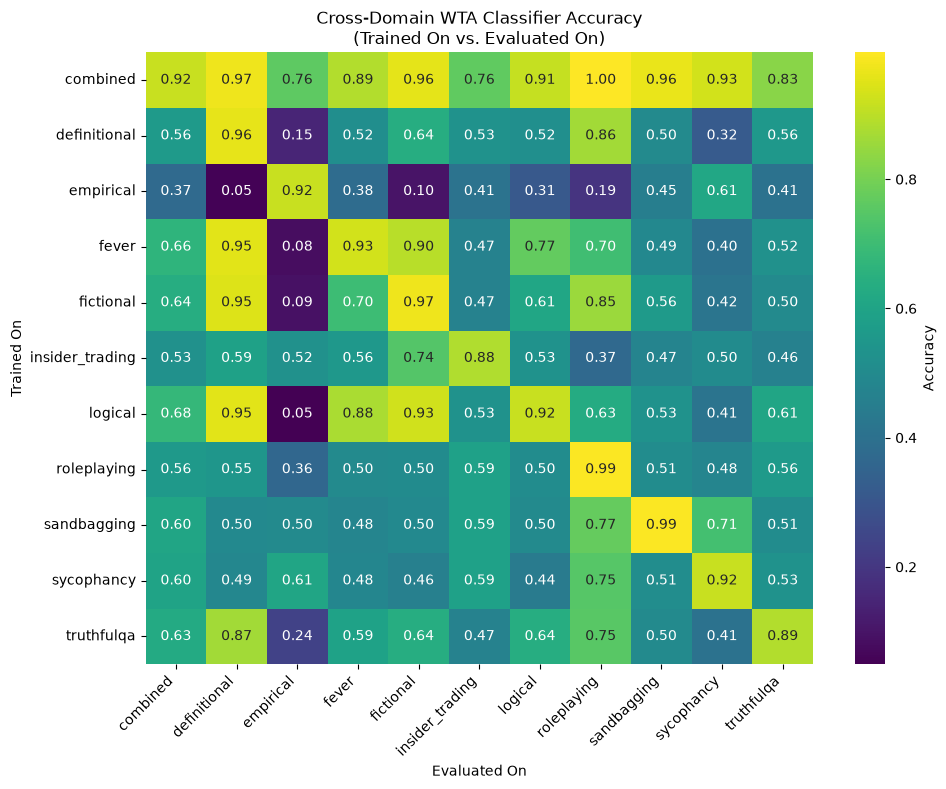

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter the metrics DataFrame for test and cross-evaluation splits
heatmap_df = metrics_df[metrics_df['split'].isin(['test', 'cross_eval'])].copy()

# Pivot the table to create a matrix of train_scope vs eval_scope for accuracy
pivot_acc = heatmap_df.pivot(index='train_scope', columns='eval_scope', values='accuracy')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_acc, annot=True, fmt=".2f", cmap="viridis", cbar_kws={'label': 'Accuracy'})
plt.title('Cross-Domain WTA Classifier Accuracy\n(Trained On vs. Evaluated On)')
plt.xlabel('Evaluated On')
plt.ylabel('Trained On')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 11. Leave-One-Out Cross-Domain Evaluation

For each domain, train a WTA classifier on **all other domains combined**, then evaluate on the held-out domain. This tests how well the model generalises to completely unseen domains.

LOO: held-out=definitional         | pool n=11209, rows=36, shared_split_counts={'train': {0: 4089, 1: 3085}, 'val': {0: 1022, 1: 772}, 'test': {0: 1277, 1: 964}}


  -> acc=0.874  auroc=0.950  f1=0.879
LOO: held-out=empirical            | pool n=11783, rows=36, shared_split_counts={'train': {0: 4272, 1: 3268}, 'val': {0: 1068, 1: 818}, 'test': {0: 1335, 1: 1022}}


  -> acc=0.131  auroc=0.079  f1=0.054
LOO: held-out=fictional            | pool n=11195, rows=36, shared_split_counts={'train': {0: 4084, 1: 3080}, 'val': {0: 1021, 1: 771}, 'test': {0: 1276, 1: 963}}


  -> acc=0.838  auroc=0.981  f1=0.859
LOO: held-out=logical              | pool n=11245, rows=36, shared_split_counts={'train': {0: 4100, 1: 3096}, 'val': {0: 1025, 1: 775}, 'test': {0: 1281, 1: 968}}


  -> acc=0.800  auroc=0.876  f1=0.781
LOO: held-out=sycophancy           | pool n=10235, rows=36, shared_split_counts={'train': {0: 3472, 1: 3078}, 'val': {0: 868, 1: 770}, 'test': {0: 1085, 1: 962}}


...

  -> acc=0.412  auroc=0.529  f1=0.000
LOO: held-out=sandbagging          | pool n=11395, rows=36, shared_split_counts={'train': {0: 4148, 1: 3144}, 'val': {0: 1037, 1: 787}, 'test': {0: 1296, 1: 983}}


  -> acc=0.695  auroc=0.786  f1=0.745
LOO: held-out=truthfulqa           | pool n=10761, rows=36, shared_split_counts={'train': {0: 3945, 1: 2941}, 'val': {0: 986, 1: 736}, 'test': {0: 1233, 1: 920}}


  -> acc=0.521  auroc=0.542  f1=0.500
LOO: held-out=fever                | pool n=10395, rows=36, shared_split_counts={'train': {0: 3828, 1: 2824}, 'val': {0: 957, 1: 707}, 'test': {0: 1196, 1: 883}}


  -> acc=0.695  auroc=0.740  f1=0.695

=== Leave-One-Out Results ===


,accuracy,auroc,f1,precision,recall,n_held_out,n_train_pool,n_train_rows
held_out_domain,,,,,,,,
fictional,0.838,0.981,0.859,0.758,0.992,240,11195,36
definitional,0.874,0.950,0.879,0.845,0.916,238,11209,36
logical,0.800,0.876,0.781,0.863,0.713,230,11245,36
roleplaying,0.737,0.853,0.633,0.508,0.838,274,11025,36
sandbagging,0.695,0.786,0.745,0.640,0.890,200,11395,36
fever,0.695,0.740,0.695,0.695,0.695,400,10395,36
truthfulqa,0.521,0.542,0.500,0.523,0.479,326,10761,36
insider_trading,0.412,0.529,0.000,0.000,0.000,17,12312,36
sycophancy,0.537,0.357,0.130,0.138,0.124,432,10235,36


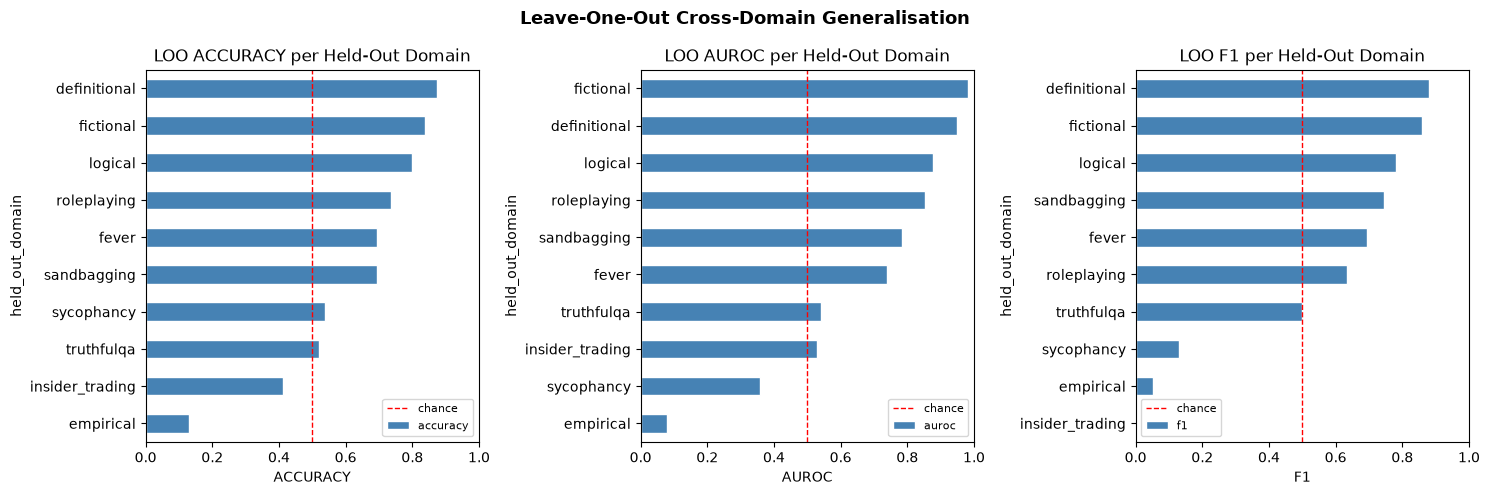

In [ ]:

# Leave-one-out: for each domain, train on all other domains' shared TRAIN split,
# tune on their shared VAL split, and evaluate on the held-out domain's shared TEST split.
loo_results = []
all_loo_domains = [d for d in DOMAINS if d in all_scope_rows]

for held_out in all_loo_domains:
    train_domains = [d for d in all_loo_domains if d != held_out]

    # Pool rows from all training domains. These rows were already extracted using shared TRAIN only.
    train_rows = np.concatenate([all_scope_rows[d] for d in train_domains], axis=0)
    train_rows = l2_normalize_rows(train_rows.astype(np.float32))

    # Pool activation examples from all training domains, then pass the shared split indices into WTA.
    X_all = acts["X_mean"]
    y_all = np.asarray(acts["y_mean"], dtype=np.int64)
    d_all = acts["domain_mean"]
    ex_all = np.asarray(acts["example_index_mean"], dtype=np.int64)

    pool_mask = np.isin(d_all, train_domains)
    X_train_pool = X_all[pool_mask]
    y_train_pool = y_all[pool_mask]
    ex_train_pool = ex_all[pool_mask]
    split_indices = make_wta_split_indices(ex_train_pool)

    if len(np.unique(y_train_pool)) < 2 or len(np.unique(y_train_pool[split_indices["train"]])) < 2:
        print(f"Skipping held-out={held_out}: training pool/shared train split has only one class.")
        continue

    print(
        f"LOO: held-out={held_out:20s} | pool n={len(y_train_pool)}, rows={train_rows.shape[0]}, "
        f"shared_split_counts={split_label_counts(y_train_pool, split_indices)}"
    )

    # Train WTA using the same shared split over the non-held-out domains.
    loo_clf, loo_artifact = train_wta(
        train_rows,
        X_train_pool,
        y_train_pool,
        split_indices=split_indices,
        example_indices=ex_train_pool,
    )
    best_th = loo_artifact["threshold"]

    # Evaluate on the held-out domain's shared test examples only.
    held_mask = (d_all == held_out) & np.isin(ex_all, GLOBAL_SPLIT_EXAMPLE_IDS["test"])
    X_held = X_all[held_mask]
    y_held = y_all[held_mask]

    if len(y_held) == 0 or len(np.unique(y_held)) < 2:
        print(f"  Skipping eval: held-out shared TEST split has only one class or is empty.")
        continue

    m = eval_clf(loo_clf, X_held, y_held, best_th)
    m["held_out_domain"] = held_out
    m["source_split"] = "shared_test"
    m["n_held_out"] = int(held_mask.sum())
    m["n_train_pool"] = int(pool_mask.sum())
    m["n_train_rows"] = train_rows.shape[0]
    loo_results.append(m)
    print(f"  -> acc={m['accuracy']:.3f}  auroc={m['auroc']:.3f}  f1={m['f1']:.3f}")

loo_df = pd.DataFrame(loo_results).set_index("held_out_domain")
loo_df = loo_df[["accuracy", "auroc", "f1", "precision", "recall", "n_held_out", "n_train_pool", "n_train_rows"]]
loo_df = loo_df.sort_values("auroc", ascending=False)

print("\n=== Leave-One-Out Results ===")
display(loo_df.style.format({
    "accuracy": "{:.3f}",
    "auroc": "{:.3f}",
    "f1": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
}).background_gradient(subset=["accuracy", "auroc", "f1"], cmap="RdYlGn", vmin=0.4, vmax=1.0))

# Bar chart summary
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ["accuracy", "auroc", "f1"]):
    loo_df[metric].sort_values().plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
    ax.axvline(0.5, color="red", linestyle="--", linewidth=1, label="chance")
    ax.set_xlabel(metric.upper())
    ax.set_title(f"LOO {metric.upper()} per Held-Out Domain")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
plt.suptitle("Leave-One-Out Cross-Domain Generalisation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Notes / common edits

- The shared example-level split is created once before INLP extraction and is reused by WTA training/validation/testing. INLP sees only shared train examples; WTA trains on the same shared train examples, tunes its threshold on shared validation examples, and reports test/cross-eval on shared held-out test examples.
- Change `LSQ_BIT_PRECISION = 3` in the config cell to sweep 2, 3, 4, 6, 8 bits.
- Change `PROJECTION_DIM = 128` to test larger or smaller learned down-projections.
- Keep `EVAL_DISTANCE_MODE = "euclidean"` if you want the baked Euclidean CAM path. Set it to `"dot"` only for debugging equivalence.
- If you want **strictly paper-style domain-specific directions**, set `REMOVE_GENERAL_BEFORE_SINGLE_DOMAIN = True`. That first removes combined/general directions before extracting single-domain rows.
- If you want the WTA classifier to be closer to the paper's example-level probes, set `TRAIN_WTA_ON = "means"`.
- If you want online token-generation detection, keep `TRAIN_WTA_ON = "tokens"`.
- If your local paper repo already contains pre-extracted activations, you can skip model extraction and directly adapt the arrays into `X_mean`, `X_token`, `y_mean`, and `y_token`.
- The saved `euclidean_baked_rows` already include the learned alphas and the extra norm dimension, so a deployment notebook only needs to project/normalize/quantize the query and do nearest-row Euclidean lookup.


## 12. Inspect the saved CAM/WTA artifact deeply

Loads the `cam_wta_GLOBAL_all_rows*.npz` deployment artifact saved in section 9 and reports its contents, as a sanity check before wrapping it for deployment in section 13.

In [ ]:
# ============================================================
# Cell 1: Inspect the saved CAM/WTA artifact deeply
# ============================================================

import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from IPython.display import display
except Exception:
    display = print


def find_latest_cam_artifact(prefer_global=True):
    """
    Finds the latest saved CAM/WTA .npz artifact from this notebook.
    Prefers the global all-row deployment artifact.
    """
    candidates = []

    # Reuse existing variables if present.
    for name in ["artifact_path", "cam_artifact_path"]:
        if name in globals():
            p = Path(globals()[name])
            if p.exists() and p.suffix == ".npz":
                candidates.append(p)

    search_dirs = []
    if "ARTIFACT_DIR" in globals():
        search_dirs.append(Path(ARTIFACT_DIR))
    if "OUTPUT_DIR" in globals():
        search_dirs.append(Path(OUTPUT_DIR) / "artifacts")
    search_dirs.append(Path.cwd())

    patterns = [
        "cam_wta_GLOBAL_all_rows*.npz",
        "cam_wta_global_all_rows*.npz",
        "cam_wta_*.npz",
    ]

    for d in search_dirs:
        if not d.exists():
            continue
        for pattern in patterns:
            candidates.extend(d.glob(pattern))

    # Deduplicate.
    seen = set()
    unique = []
    for p in candidates:
        p = p.resolve()
        if p not in seen and p.exists():
            seen.add(p)
            unique.append(p)

    if not unique:
        raise FileNotFoundError(
            "No CAM/WTA .npz artifact found. Run the notebook save-artifact cell first."
        )

    if prefer_global:
        global_candidates = [p for p in unique if "GLOBAL_all_rows" in p.name or "global_all_rows" in p.name]
        if global_candidates:
            unique = global_candidates

    unique = sorted(unique, key=lambda p: p.stat().st_mtime, reverse=True)
    return unique[0]


def npz_scalar(z, key, default=None, cast=None):
    if key not in z.files:
        return default
    val = np.asarray(z[key]).reshape(-1)[0]
    if cast is not None:
        return cast(val)
    return val


def npz_json(z, key, default=None):
    if key not in z.files:
        return {} if default is None else default
    raw = np.asarray(z[key]).reshape(-1)[0]
    return json.loads(str(raw))


def l2_norm(x, axis=-1, eps=1e-12):
    return np.sqrt(np.maximum(np.sum(np.asarray(x) ** 2, axis=axis), eps))


def downsample_columns(mat, max_cols=512, reducer="mean"):
    """
    Downsample very wide matrices for heatmaps.
    For CAM rows in 8192 dimensions, plotting every coordinate is too dense,
    so this bins columns while preserving row structure.
    """
    mat = np.asarray(mat)
    n_rows, n_cols = mat.shape

    if n_cols <= max_cols:
        return mat, np.arange(n_cols), False

    edges = np.linspace(0, n_cols, max_cols + 1, dtype=int)
    binned = []

    for a, b in zip(edges[:-1], edges[1:]):
        block = mat[:, a:b]
        if reducer == "mean_abs":
            binned.append(np.mean(np.abs(block), axis=1))
        elif reducer == "max_abs":
            idx = np.argmax(np.abs(block), axis=1)
            binned.append(block[np.arange(n_rows), idx])
        else:
            binned.append(np.mean(block, axis=1))

    return np.stack(binned, axis=1), edges[:-1], True


def plot_heatmap(
    mat,
    title,
    xlabel,
    ylabel="CAM row",
    max_cols=512,
    reducer="mean",
    center_zero=True,
    integer_ticks=False,
    row_names=None,
):
    mat = np.asarray(mat)
    view, col_labels, was_binned = downsample_columns(mat, max_cols=max_cols, reducer=reducer)

    plt.figure(figsize=(min(20, max(10, view.shape[1] / 24)), min(14, max(4, view.shape[0] * 0.25))))

    if center_zero:
        vmax = np.nanpercentile(np.abs(view), 99)
        if vmax <= 0 or not np.isfinite(vmax):
            vmax = 1.0
        im = plt.imshow(view, aspect="auto", interpolation="nearest", cmap="coolwarm", vmin=-vmax, vmax=vmax)
    else:
        im = plt.imshow(view, aspect="auto", interpolation="nearest", cmap="viridis")

    plt.colorbar(im, fraction=0.025, pad=0.02)
    suffix = " — binned columns" if was_binned else ""
    plt.title(title + suffix)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if row_names is not None and len(row_names) == view.shape[0] and view.shape[0] <= 80:
        plt.yticks(np.arange(view.shape[0]), [str(r)[:70] for r in row_names], fontsize=7)

    if was_binned:
        xticks = np.linspace(0, view.shape[1] - 1, min(10, view.shape[1]), dtype=int)
        plt.xticks(xticks, [str(int(col_labels[i])) for i in xticks], rotation=45, ha="right")
    elif view.shape[1] <= 160:
        xticks = np.linspace(0, view.shape[1] - 1, min(16, view.shape[1]), dtype=int)
        plt.xticks(xticks, [str(int(i)) for i in xticks])

    if integer_ticks:
        plt.title(title + suffix + "  | integer quantization codes")

    plt.tight_layout()
    plt.show()


def top_coordinates_table(mat, row_names, matrix_name, n_rows=8, top_k=12):
    """
    Show the largest-magnitude coordinates for the first few rows.
    """
    mat = np.asarray(mat)
    records = []
    n_rows = min(n_rows, mat.shape[0])

    for i in range(n_rows):
        idx = np.argsort(-np.abs(mat[i]))[:top_k]
        for rank, j in enumerate(idx, start=1):
            records.append({
                "matrix": matrix_name,
                "row_index": i,
                "row_name": row_names[i] if row_names is not None else f"row_{i}",
                "rank": rank,
                "coordinate": int(j),
                "value": float(mat[i, j]),
                "abs_value": float(abs(mat[i, j])),
            })

    return pd.DataFrame(records)


# ------------------------------------------------------------
# Load artifact
# ------------------------------------------------------------

cam_artifact_path = find_latest_cam_artifact(prefer_global=True)
z = np.load(cam_artifact_path, allow_pickle=True)

print("Loaded CAM artifact:")
print(" ", cam_artifact_path)
print()
print("Keys:")
print(" ", sorted(z.files))
print()

cam_rows = z["cam_rows"].astype(np.float32)                              # original dense CAM rows, [K, d_model]
rows_projected_fp32 = z["rows_projected_fp32"].astype(np.float32)         # projected rows before quantization, [K, d_proj]
rows_projected_quantized = z["rows_projected_quantized"].astype(np.float32)
euclidean_baked_rows = z["euclidean_baked_rows"].astype(np.float32)       # [K, d_proj + 1]
projection_weight = z["projection_weight"].astype(np.float32)

alphas = z["alphas"].astype(np.float32)
bias = float(np.asarray(z["bias"]).reshape(-1)[0])
threshold = float(np.asarray(z["threshold"]).reshape(-1)[0])
euclidean_constant = float(np.asarray(z["euclidean_constant"]).reshape(-1)[0])

row_names = [str(x) for x in z["row_names"]]
row_metadata = npz_json(z, "row_metadata_json", default=[])
metrics = npz_json(z, "metrics_json", default=[])
history = npz_json(z, "history_json", default=[])
act_quant = npz_json(z, "act_quant_json", default={})
row_quant = npz_json(z, "row_quant_json", default={})

model_id = str(npz_scalar(z, "model_id", "unknown"))
layer_index = int(npz_scalar(z, "layer_index", -1))
hidden_state_mode = str(npz_scalar(z, "hidden_state_mode", "unknown"))
positive_label_name = str(npz_scalar(z, "positive_label_name", "unknown"))
projection_dim = int(npz_scalar(z, "projection_dim", rows_projected_quantized.shape[1]))
lsq_bit_precision = int(npz_scalar(z, "lsq_bit_precision", -1))
eval_distance_mode = str(npz_scalar(z, "eval_distance_mode", "unknown"))

K, d_model = cam_rows.shape
d_proj = rows_projected_quantized.shape[1]

print("Artifact summary")
print("  model_id:", model_id)
print("  layer_index:", layer_index)
print("  hidden_state_mode:", hidden_state_mode)
print("  positive label:", positive_label_name)
print("  K rows:", K)
print("  d_model:", d_model)
print("  d_proj:", d_proj)
print("  projection_weight:", projection_weight.shape)
print("  cam_rows:", cam_rows.shape)
print("  rows_projected_fp32:", rows_projected_fp32.shape)
print("  rows_projected_quantized:", rows_projected_quantized.shape)
print("  euclidean_baked_rows:", euclidean_baked_rows.shape)
print("  eval_distance_mode:", eval_distance_mode)
print()

print("Quantization metadata")
print("  activation/query quantizer:", act_quant)
print("  row quantizer:", row_quant)
print()

print("Classifier scalars")
print("  bias:", bias)
print("  threshold:", threshold)
print("  threshold minus bias:", threshold - bias)
print("  euclidean_constant:", euclidean_constant)
print("  alpha range:", float(alphas.min()), "to", float(alphas.max()))
print("  alpha mean/std:", float(alphas.mean()), float(alphas.std()))
print()

# ------------------------------------------------------------
# Baked-row interpretation
# ------------------------------------------------------------

weighted_rows_from_quantized = rows_projected_quantized * alphas[:, None]
baked_weighted_part = euclidean_baked_rows[:, :-1]
baked_extra_dim = euclidean_baked_rows[:, -1]

baked_weight_error = np.max(np.abs(weighted_rows_from_quantized - baked_weighted_part))
baked_norm_sq = np.sum(euclidean_baked_rows ** 2, axis=1)
weighted_norm_sq = np.sum(weighted_rows_from_quantized ** 2, axis=1)

print("Baked Euclidean row check")
print("  euclidean_baked_rows[:, :-1] should equal alphas[:, None] * rows_projected_quantized")
print("  max absolute baked-weight error:", float(baked_weight_error))
print("  baked row norm^2 min/max:", float(baked_norm_sq.min()), float(baked_norm_sq.max()))
print("  saved euclidean_constant:", euclidean_constant)
print("  max |norm^2 - euclidean_constant|:", float(np.max(np.abs(baked_norm_sq - euclidean_constant))))
print()
print("Note:")
print("  alphas are baked into euclidean_baked_rows[:, :-1].")
print("  the extra final coordinate makes every baked row have the same norm.")
print("  bias is NOT inside the row vectors; it is added after distance-to-logit conversion.")
print("  threshold is also scalar metadata used after the logit is computed.")
print()

# ------------------------------------------------------------
# Integer quantization codes for the CAM rows
# ------------------------------------------------------------

row_scale = float(row_quant.get("scale", np.nan))
row_qmin = int(row_quant.get("qmin", -999999))
row_qmax = int(row_quant.get("qmax", 999999))

act_scale = float(act_quant.get("scale", np.nan))
act_qmin = int(act_quant.get("qmin", -999999))
act_qmax = int(act_quant.get("qmax", 999999))

if np.isfinite(row_scale) and row_scale > 0:
    row_integer_codes = np.rint(rows_projected_quantized / row_scale).astype(np.int32)
else:
    row_integer_codes = None

# ------------------------------------------------------------
# Per-row diagnostic table
# ------------------------------------------------------------

diag = pd.DataFrame({
    "row_index": np.arange(K),
    "row_name": row_names,
    "alpha_weight": alphas,
    "baked_extra_dim": baked_extra_dim,
    "original_cam_l2": l2_norm(cam_rows, axis=1),
    "projected_fp32_l2": l2_norm(rows_projected_fp32, axis=1),
    "projected_quantized_l2": l2_norm(rows_projected_quantized, axis=1),
    "weighted_quantized_l2": l2_norm(weighted_rows_from_quantized, axis=1),
    "baked_l2": l2_norm(euclidean_baked_rows, axis=1),
    "max_abs_original_cam_coord": np.max(np.abs(cam_rows), axis=1),
    "max_abs_projected_q_coord": np.max(np.abs(rows_projected_quantized), axis=1),
    "argmax_abs_original_cam_coord": np.argmax(np.abs(cam_rows), axis=1),
    "argmax_abs_projected_q_coord": np.argmax(np.abs(rows_projected_quantized), axis=1),
})

if row_integer_codes is not None:
    diag["quant_int_min"] = row_integer_codes.min(axis=1)
    diag["quant_int_max"] = row_integer_codes.max(axis=1)
    diag["quant_nonzero_frac"] = np.mean(row_integer_codes != 0, axis=1)
    diag["quant_saturation_frac"] = np.mean(
        (row_integer_codes == row_qmin) | (row_integer_codes == row_qmax),
        axis=1,
    )
    diag["quant_negative_frac"] = np.mean(row_integer_codes < 0, axis=1)
    diag["quant_positive_frac"] = np.mean(row_integer_codes > 0, axis=1)

print("Per-row diagnostics")
display(diag)

# ------------------------------------------------------------
# Domain/scope counts if metadata is available
# ------------------------------------------------------------

if isinstance(row_metadata, list) and len(row_metadata) == K:
    meta_df = pd.DataFrame(row_metadata)
    print("Row metadata")
    display(meta_df)

    if "scope" in meta_df.columns:
        print("Row counts by scope")
        display(meta_df["scope"].value_counts().rename_axis("scope").reset_index(name="n_rows"))

# ------------------------------------------------------------
# Training history / metrics summaries if available
# ------------------------------------------------------------

if isinstance(metrics, list) and len(metrics) > 0:
    print("Saved validation/test metrics")
    display(pd.DataFrame(metrics))

if isinstance(history, list) and len(history) > 0:
    hist_df = pd.DataFrame(history)
    print("Training history tail")
    display(hist_df.tail(10))

    cols = [c for c in ["epoch", "loss", "val_auc", "act_scale", "row_scale"] if c in hist_df.columns]
    if len(cols) > 1:
        display(hist_df[cols].describe())

# ------------------------------------------------------------
# Actual vector-value heatmaps
# ------------------------------------------------------------

plot_heatmap(
    rows_projected_quantized,
    title="Actual stored projected quantized CAM rows",
    xlabel="projected coordinate",
    ylabel="CAM row",
    max_cols=512,
    reducer="mean",
    center_zero=True,
    row_names=row_names,
)

if row_integer_codes is not None:
    plot_heatmap(
        row_integer_codes,
        title=f"Integer quantization codes of projected CAM rows, scale={row_scale:.6g}",
        xlabel="projected coordinate",
        ylabel="CAM row",
        max_cols=512,
        reducer="mean",
        center_zero=True,
        integer_ticks=True,
        row_names=row_names,
    )

plot_heatmap(
    weighted_rows_from_quantized,
    title="Weighted projected CAM rows: alpha_j * quantized_row_j",
    xlabel="projected coordinate",
    ylabel="CAM row",
    max_cols=512,
    reducer="mean",
    center_zero=True,
    row_names=row_names,
)

plot_heatmap(
    euclidean_baked_rows,
    title="Euclidean baked CAM rows: [alpha_j * row_j, extra_norm_dim_j]",
    xlabel="projected coordinate plus final norm coordinate",
    ylabel="CAM row",
    max_cols=512,
    reducer="mean",
    center_zero=True,
    row_names=row_names,
)

plot_heatmap(
    cam_rows,
    title="Original dense CAM rows in model residual space",
    xlabel="model residual coordinate",
    ylabel="CAM row",
    max_cols=512,
    reducer="mean",
    center_zero=True,
    row_names=row_names,
)

plot_heatmap(
    cam_rows,
    title="Original dense CAM rows: mean absolute magnitude by coordinate bin",
    xlabel="model residual coordinate",
    ylabel="CAM row",
    max_cols=512,
    reducer="mean_abs",
    center_zero=False,
    row_names=row_names,
)

# ------------------------------------------------------------
# Scalar plots
# ------------------------------------------------------------

plt.figure(figsize=(12, 4))
plt.plot(np.arange(K), alphas, marker="o")
plt.title("Learned nonnegative row weights alpha_j")
plt.xlabel("CAM row index")
plt.ylabel("alpha_j")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(np.arange(K), baked_extra_dim, marker="o")
plt.title("Extra Euclidean norm coordinate per baked CAM row")
plt.xlabel("CAM row index")
plt.ylabel("extra coordinate")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(np.arange(K), weighted_norm_sq, marker="o", label="||alpha_j * row_j||^2")
plt.plot(np.arange(K), baked_norm_sq, marker=".", label="||baked_row_j||^2")
plt.axhline(euclidean_constant, linestyle="--", label="saved Euclidean constant")
plt.title("Weighted row norms before and after Euclidean baking")
plt.xlabel("CAM row index")
plt.ylabel("squared norm")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Top coordinate tables
# ------------------------------------------------------------

print("Largest coordinates in projected quantized CAM rows")
display(top_coordinates_table(
    rows_projected_quantized,
    row_names=row_names,
    matrix_name="rows_projected_quantized",
    n_rows=min(8, K),
    top_k=12,
))

print("Largest coordinates in original dense CAM rows")
display(top_coordinates_table(
    cam_rows,
    row_names=row_names,
    matrix_name="cam_rows_original_residual_space",
    n_rows=min(8, K),
    top_k=12,
))

if row_integer_codes is not None:
    print("Largest integer quantization codes in projected CAM rows")
    display(top_coordinates_table(
        row_integer_codes,
        row_names=row_names,
        matrix_name="row_integer_codes",
        n_rows=min(8, K),
        top_k=12,
    ))

print("Done. Main variables now available:")
print("  cam_artifact_path")
print("  cam_rows")
print("  rows_projected_fp32")
print("  rows_projected_quantized")
print("  euclidean_baked_rows")
print("  alphas")
print("  bias")
print("  threshold")
print("  row_names")
print("  diag")

## 13. Minimal deployment classifier (`CAMDeceptionClassifier`)

A self-contained class that loads only the deployment-time tensors from the saved artifact (projection matrix, quantized rows, alphas, Euclidean-baked rows, quantization scale, bias, threshold) and exposes `classify()` / `classify_with_score()` for live use.

In [ ]:
# ============================================================
# Section 13: Minimal self-contained CAM deception classifier
# ============================================================

import json
import torch
import numpy as np
from pathlib import Path


class CAMDeceptionClassifier:
    """
    Minimal CAM/WTA classifier.

    Holds only plain torch tensors (no pickled object state). This is deliberate:
    pickling a class instance requires the exact CAMDeceptionClassifier class
    definition to be importable wherever you unpickle it later, which is brittle
    across environments/versions. Instead, deployment state is saved as a plain
    tensor dict (section 14) and this class just knows how to read that dict.
    Ship this class definition as source alongside the tensor file.

    Input:
      x: residual stream activation
         shape [d_model] or [n_tokens, d_model] or [batch, d_model]
         (numpy array or torch tensor)

    Output:
      classify(x) -> (deception_detected, vector_index)

    Notes:
      - If x is [n_tokens, d_model], pooling follows `self.pooling_mode`:
        "last" (default, matches live token-by-token streaming, where only the
        most recent token's activation is available) or "mean".
      - Deployment-time tensors only:
          projection matrix
          quantized CAM rows
          alpha weights
          Euclidean-baked rows
          quantization scale
          bias
          threshold
    """

    def __init__(self, tensors_path=None, device="cpu"):
        tensors_path = Path(tensors_path) if tensors_path is not None else self._find_tensors()
        state = torch.load(tensors_path, map_location=device, weights_only=True)

        self.tensors_path = str(tensors_path)
        self.device = torch.device(device)

        # Deployment tensors only — plain torch tensors, no class state besides these.
        self.P = state["projection_weight"].to(self.device, dtype=torch.float32)
        self.rows_q = state["rows_projected_quantized"].to(self.device, dtype=torch.float32)
        self.rows_euclidean = state["euclidean_baked_rows"].to(self.device, dtype=torch.float32)
        self.alphas = state["alphas"].to(self.device, dtype=torch.float32)

        self.bias = float(state["bias"])
        self.threshold = float(state["threshold"])
        self.C = float(state["euclidean_constant"])
        self.q_scale = float(state["act_quant_scale"])
        self.qmin = int(state["act_quant_qmin"])
        self.qmax = int(state["act_quant_qmax"])
        self.pooling_mode = str(state.get("pooling_mode", "last"))

        self.row_names = list(state["row_names"])
        self.d_proj = self.rows_q.shape[1]
        self.d_model = self.P.shape[1]
        self.K = self.rows_q.shape[0]

    @staticmethod
    def _find_tensors():
        search_dirs = [Path.cwd()]

        if "ARTIFACT_DIR" in globals():
            search_dirs.insert(0, Path(ARTIFACT_DIR))

        if "OUTPUT_DIR" in globals():
            search_dirs.insert(0, Path(OUTPUT_DIR) / "artifacts")

        candidates = []
        for d in search_dirs:
            if d.exists():
                candidates += list(d.glob("cam_deception_classifier*.pt"))

        if not candidates:
            raise FileNotFoundError("No CAM/WTA tensor file (*.pt) found.")

        return sorted(candidates, key=lambda p: p.stat().st_mtime, reverse=True)[0]

    def _prepare_x(self, x):
        x = torch.as_tensor(np.asarray(x), dtype=torch.float32, device=self.device) if not torch.is_tensor(x) else x.to(self.device, dtype=torch.float32)

        if x.ndim == 1:
            # One residual vector: [d_model]
            x = x[None, :]

        elif x.ndim == 2:
            if x.shape[1] != self.d_model:
                raise ValueError(f"Expected last dimension d_model={self.d_model}, got {tuple(x.shape)}")
            # [batch, d_model]: treated as a batch of already-pooled vectors.

        elif x.ndim == 3:
            # Batch of token residual streams: [batch, tokens, d_model]
            if x.shape[-1] != self.d_model:
                raise ValueError(f"Expected final dimension d_model={self.d_model}, got {tuple(x.shape)}")
            x = x[:, -1, :] if self.pooling_mode == "last" else x.mean(dim=1)

        else:
            raise ValueError(f"Unsupported input shape: {tuple(x.shape)}")

        return x

    def _encode(self, x):
        x = self._prepare_x(x)

        # Project residual activation to CAM space.
        q = x @ self.P.T

        # Normalize.
        q = q / (q.norm(dim=1, keepdim=True) + 1e-8)

        # Quantize using learned activation scale.
        q = torch.clamp(torch.round(q / self.q_scale), self.qmin, self.qmax) * self.q_scale

        return q

    def classify(self, x):
        """
        Returns:
            single input:
                (deception_detected: bool, vector_index: int)

            batch input:
                list[(deception_detected: bool, vector_index: int)]
        """
        q = self._encode(x)

        # Euclidean CAM lookup.
        # Query is augmented with a zero in the final coordinate.
        q_aug = torch.cat([q, torch.zeros(q.shape[0], 1, device=self.device)], dim=1)

        dist_sq = ((q_aug[:, None, :] - self.rows_euclidean[None, :, :]) ** 2).sum(dim=-1)

        min_dist_sq, winner = dist_sq.min(dim=1)
        q_norm_sq = (q ** 2).sum(dim=1)

        # Convert nearest-row distance back to max-dot-product logit.
        logits = -0.5 * (min_dist_sq - q_norm_sq - self.C) + self.bias

        detected = logits >= self.threshold

        out = [(bool(d), int(i)) for d, i in zip(detected.tolist(), winner.tolist())]

        return out[0] if len(out) == 1 else out

    def classify_with_score(self, x):
        """
        Same as classify(), but also returns the logit and row name.

        Returns:
            single input:
                (deception_detected, vector_index, vector_name, logit)

            batch input:
                list[(deception_detected, vector_index, vector_name, logit)]
        """
        q = self._encode(x)

        q_aug = torch.cat([q, torch.zeros(q.shape[0], 1, device=self.device)], dim=1)

        dist_sq = ((q_aug[:, None, :] - self.rows_euclidean[None, :, :]) ** 2).sum(dim=-1)

        min_dist_sq, winner = dist_sq.min(dim=1)
        q_norm_sq = (q ** 2).sum(dim=1)

        logits = -0.5 * (min_dist_sq - q_norm_sq - self.C) + self.bias
        detected = logits >= self.threshold

        out = [
            (bool(d), int(i), self.row_names[int(i)], float(logit))
            for d, i, logit in zip(detected.tolist(), winner.tolist(), logits.tolist())
        ]

        return out[0] if len(out) == 1 else out


# Instantiate from the .npz artifact for in-notebook use; section 14 re-saves this
# classifier's state as a plain tensor file for portable deployment elsewhere.
def _cam_classifier_from_npz(npz_path):
    z = np.load(npz_path, allow_pickle=True)
    act_quant = json.loads(str(np.asarray(z["act_quant_json"]).reshape(-1)[0]))
    state = {
        "projection_weight": torch.as_tensor(z["projection_weight"], dtype=torch.float32),
        "rows_projected_quantized": torch.as_tensor(z["rows_projected_quantized"], dtype=torch.float32),
        "euclidean_baked_rows": torch.as_tensor(z["euclidean_baked_rows"], dtype=torch.float32),
        "alphas": torch.as_tensor(z["alphas"], dtype=torch.float32),
        "bias": float(np.asarray(z["bias"]).reshape(-1)[0]),
        "threshold": float(np.asarray(z["threshold"]).reshape(-1)[0]),
        "euclidean_constant": float(np.asarray(z["euclidean_constant"]).reshape(-1)[0]),
        "act_quant_scale": float(act_quant["scale"]),
        "act_quant_qmin": int(act_quant["qmin"]),
        "act_quant_qmax": int(act_quant["qmax"]),
        "row_names": [str(r) for r in z["row_names"]],
        "pooling_mode": POOLING_MODE if "POOLING_MODE" in globals() else "last",
    }
    tmp_path = Path(npz_path).with_suffix(".tmp_state.pt")
    torch.save(state, tmp_path)
    clf = CAMDeceptionClassifier(tmp_path)
    tmp_path.unlink()
    return clf


_npz_candidates = sorted(
    Path(ARTIFACT_DIR).glob("cam_wta_GLOBAL_all_rows*.npz"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
) if "ARTIFACT_DIR" in globals() else []
if not _npz_candidates:
    raise FileNotFoundError("No cam_wta_GLOBAL_all_rows*.npz artifact found in ARTIFACT_DIR.")

cam_classifier = _cam_classifier_from_npz(_npz_candidates[0])

print("Loaded from:", _npz_candidates[0])
print("Rows:", cam_classifier.K)
print("Residual dimension:", cam_classifier.d_model)
print("Projected CAM dimension:", cam_classifier.d_proj)
print("Pooling mode:", cam_classifier.pooling_mode)
print("Threshold:", cam_classifier.threshold)
print("Bias:", cam_classifier.bias)
print()
print("Usage:")
print("  detected, vector_index = cam_classifier.classify(x)")
print("  detected, vector_index, vector_name, logit = cam_classifier.classify_with_score(x)")

## 14. Save CAM tensors for live token-level analysis

Saves the deployment tensors (not a pickled object) to a `.pt` file. Reload elsewhere by copying the `CAMDeceptionClassifier` class source from section 13 and calling `CAMDeceptionClassifier("cam_deception_classifier.pt")`.

In [ ]:
# ============================================================
# Section 14: Save the CAM vectors as plain torch tensors and download
# ============================================================
#
# Deliberately NOT pickling the CAMDeceptionClassifier instance: a standard
# pickle stores object state, but loading it back also requires the exact
# CAMDeceptionClassifier class definition to be importable in that session.
# Instead we save only the deployment tensors (a plain dict of torch tensors
# + a few scalars/metadata) via torch.save. To use this elsewhere, copy the
# CAMDeceptionClassifier class source from section 13 and do:
#   clf = CAMDeceptionClassifier("cam_deception_classifier.pt")

import torch
from pathlib import Path

if "cam_classifier" not in globals():
    raise RuntimeError("Run section 13 first to build cam_classifier.")

clf = cam_classifier
tensors_path = Path("cam_deception_classifier.pt")

state = {
    "projection_weight": clf.P.detach().cpu(),
    "rows_projected_quantized": clf.rows_q.detach().cpu(),
    "euclidean_baked_rows": clf.rows_euclidean.detach().cpu(),
    "alphas": clf.alphas.detach().cpu(),
    "bias": torch.tensor(clf.bias),
    "threshold": torch.tensor(clf.threshold),
    "euclidean_constant": torch.tensor(clf.C),
    "act_quant_scale": torch.tensor(clf.q_scale),
    "act_quant_qmin": torch.tensor(clf.qmin),
    "act_quant_qmax": torch.tensor(clf.qmax),
    "row_names": clf.row_names,
    "pooling_mode": clf.pooling_mode,
}

torch.save(state, tensors_path)

print(f"Saved CAM tensors to: {tensors_path.resolve()}")
print(f"File size: {tensors_path.stat().st_size / 1024:.2f} KB")
print("Reload elsewhere with: CAMDeceptionClassifier('cam_deception_classifier.pt')")
print("(requires the CAMDeceptionClassifier class source from section 13 to be available there)")

# Download in Colab, otherwise show a clickable Jupyter link.
try:
    from google.colab import files
    files.download(str(tensors_path))
except Exception:
    try:
        from IPython.display import FileLink, display
        display(FileLink(str(tensors_path)))
    except Exception:
        print("Download link unavailable in this environment.")
        print("Tensor file is saved at:", tensors_path.resolve())